# Notebook 03 — Integrated SCVR: Multi-Model CMIP6 Ensemble

**What this notebook does:**

1. **Fetches multi-model CMIP6 ensemble data** via NASA NEX-GDDP-CMIP6 THREDDS (pipeline from Notebook 02)
2. **Computes SCVR** (Severe Climate Variability Rating) on pooled daily data (math from Notebook 01)
3. **Uses dynamic asset timelines** — `construction_start_year` + `operational_lifespan` define the exact future window
4. **Compares SSP2-4.5 vs SSP5-8.5** side-by-side for each climate variable

```
  Notebook 01 (SCVR Math)          Notebook 02 (THREDDS Pipeline)
  ┌──────────────────────┐         ┌──────────────────────────────┐
  │ compute_scvr()       │         │ fetch_year() via NCSS        │
  │ exceedance area      │         │ multi-model probing          │
  │ integral (trapezoid) │         │ cftime calendar handling     │
  └─────────┬────────────┘         └──────────────┬───────────────┘
            │                                      │
            └──────────────┬───────────────────────┘
                           ▼
              THIS NOTEBOOK (03)
              ┌────────────────────────────────────────────┐
              │ Dynamic asset timeline (2026–2055)          │
              │ Pool N models x 30 years of daily data      │
              │ SCVR per variable per scenario               │
              │ → feeds HCR/EFR in Notebook 04               │
              └────────────────────────────────────────────┘
```

**Data source:** NASA NEX-GDDP-CMIP6 via NCCS THREDDS NetCDF Subset Service
- Server-side point extraction (KB per request, not GB)
- No login required
- True SSP scenario separation (unlike Open-Meteo HighResMIP)

---
**Quick Navigation**

| Resource | Link |
|---|---|
| Implementation doc (design decisions, outputs, limitations) | [`docs/implementation/03_integrated_scvr_cmip6.md`](../docs/implementation/03_integrated_scvr_cmip6.md) |
| Build plan | [`docs/plan/plan.md`](../docs/plan/plan.md) |
| SCVR methodology explained | [`docs/learning/04_scvr_methodology.md`](../docs/learning/04_scvr_methodology.md) |
| THREDDS pipeline explained | [`docs/learning/05_data_pipeline.md`](../docs/learning/05_data_pipeline.md) |
| Baseline vs future periods | [`docs/learning/06_baseline_vs_future.md`](../docs/learning/06_baseline_vs_future.md) |
| Climate → finance chain | [`docs/learning/07_from_climate_to_finance.md`](../docs/learning/07_from_climate_to_finance.md) |
| Project TODO / roadmap | [`docs/todo.md`](../docs/todo.md) |

---

In [ ]:
# ── Inline installs (idempotent) ──────────────────────────────────────────────
%pip install -q xarray cftime tqdm seaborn scipy

import warnings
warnings.filterwarnings("ignore")

import json
import sys
import numpy as np
import pandas as pd
import xarray as xr
import cftime
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import seaborn as sns
import requests
import io
import time
from pathlib import Path
from tqdm.notebook import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy import stats as sp_stats

# ── Import shared utilities ───────────────────────────────────────────────────
sys.path.insert(0, str(Path("../scripts/shared").resolve()))
try:
    from scvr_utils import (
        compute_anchor_fit, compute_decade_scvr, compute_decade_shape,
        compute_shape_metrics, fit_gev, exceedance_curve_gev,
        fit_gpd, exceedance_curve_gpd,
        exceedance_curve_empirical, pool_window, variable_scvr_strategy,
        DEFAULT_DECADES, DEFAULT_ANCHOR_3, DEFAULT_SCVR_STRATEGY,
    )
    SHARED_AVAILABLE = True
    print("Imports OK (shared module loaded)")
except ImportError:
    SHARED_AVAILABLE = False
    print("Imports OK (shared module not found — using inline functions)")

In [ ]:
# ── Load canonical schemas ────────────────────────────────────────────────────
SCHEMA_DIR = Path("../data/schema")
with open(SCHEMA_DIR / "sites.json") as f:
    SITES_RAW = json.load(f)
with open(SCHEMA_DIR / "variables.json") as f:
    VARS_RAW = json.load(f)
with open(SCHEMA_DIR / "scvr_schema.json") as f:
    SCVR_SCHEMA = json.load(f)

# ── Site configs — extend with asset timeline ─────────────────────────────────
SITE_CONFIGS = {}
for sid in ["hayhurst_solar", "maverick_wind"]:
    s = SITES_RAW[sid]
    SITE_CONFIGS[sid] = {
        "name": s["name"],
        "asset_type": s["asset_type"],
        "lat": s["lat"],
        "lon": s["lon"],
        "capacity_mw": s["capacity_mw"],
        "construction_start_year": 2026,
        "operational_lifespan": 30,  # years → 2026–2055
    }

# ── Scenarios ─────────────────────────────────────────────────────────────────
SCENARIOS = ["ssp245", "ssp585"]
BASELINE_YEARS = (1985, 2014)

# ── Variables per site (P1_core for both, + rsds P2 for solar only) ───────────
P1_VARS = [k for k, v in VARS_RAW.items()
           if isinstance(v, dict) and v.get("priority") == "P1_core"]
SITE_VARIABLES = {
    "hayhurst_solar": P1_VARS + ["rsds"],   # solar gets irradiance
    "maverick_wind":  P1_VARS,
}

# ── Full CMIP6 model list (34 NEX-GDDP models) ──────────────────────────────
ALL_MODELS = [
    "ACCESS-CM2","ACCESS-ESM1-5","BCC-CSM2-MR","CanESM5","CESM2",
    "CESM2-LENS","CMCC-CM2-SR5","CMCC-ESM2","CNRM-CM6-1","CNRM-ESM2-1",
    "EC-Earth3","EC-Earth3-Veg-LR","FGOALS-g3","GFDL-CM4","GFDL-CM4_gr2",
    "GFDL-ESM4","GISS-E2-1-G","HadGEM3-GC31-LL","HadGEM3-GC31-MM",
    "IITM-ESM","INM-CM4-8","INM-CM5-0","IPSL-CM6A-LR","KACE-1-0-G",
    "KIOST-ESM","MIROC6","MPI-ESM1-2-HR","MPI-ESM1-2-LR","MRI-ESM2-0",
    "NESM3","NorESM2-LM","NorESM2-MM","TaiESM1","UKESM1-0-LL",
]
MAX_MODELS = None  # Use all available models (was 6 — expanded per Prashant review)

# ── Decade windows for progression analysis ───────────────────────────────────
DECADE_WINDOWS = [
    ("2026-2035", 2026, 2035),
    ("2036-2045", 2036, 2045),
    ("2046-2055", 2046, 2055),
]

# ── Anchor configs ────────────────────────────────────────────────────────────
ANCHOR_3 = [(2026, 2035), (2036, 2045), (2046, 2055)]

# ── Variable-specific SCVR strategy ──────────────────────────────────────────
#   Temperature: 3-anchor + linear fit (R² > 0.95, clean warming trend)
#   Precipitation/humidity: period average (noisy, non-linear)
#   Wind/radiation: period average (SCVR ≈ 0, no signal)
# See: docs/discussion/discussion_annual_scvr_methodology.md §14
SCVR_STRATEGY = {
    "tasmax": "anchor_3_linear", "tasmin": "anchor_3_linear", "tas": "anchor_3_linear",
    "pr": "period_average", "hurs": "period_average",
    "sfcWind": "period_average", "rsds": "period_average",
}

# ── THREDDS endpoint & cache ─────────────────────────────────────────────────
THREDDS_NCSS = "https://ds.nccs.nasa.gov/thredds/ncss/grid/AMES/NEX/GDDP-CMIP6"
CACHE_DIR = Path("../data/cache/thredds")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ── Output directories ────────────────────────────────────────────────────────
for sid in SITE_CONFIGS:
    Path(f"../data/processed/scvr/{sid}").mkdir(parents=True, exist_ok=True)

# ── Config summary ────────────────────────────────────────────────────────────
print("=" * 70)
print("CONFIGURATION SUMMARY")
print("=" * 70)
for sid, cfg in SITE_CONFIGS.items():
    end_yr = cfg["construction_start_year"] + cfg["operational_lifespan"] - 1
    print(f"\n  {sid}:")
    print(f"    {cfg['name']}  ({cfg['lat']:.4f}N, {cfg['lon']:.4f}W)")
    print(f"    Asset lifetime: {cfg['construction_start_year']}–{end_yr}")
    print(f"    Variables: {SITE_VARIABLES[sid]}")
print(f"\n  Scenarios:  {SCENARIOS}")
print(f"  Baseline:   {BASELINE_YEARS[0]}–{BASELINE_YEARS[1]}")
cap_str = f"cap {MAX_MODELS}" if MAX_MODELS else "all available"
print(f"  Models:     {len(ALL_MODELS)} total, {cap_str} per combo")
print(f"  Decades:    {[d[0] for d in DECADE_WINDOWS]}")
print(f"  Strategy:   variable-specific (anchor for temp, avg for others)")
print("=" * 70)

In [3]:
# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({"figure.dpi": 150, "font.size": 10, "axes.titlesize": 12})
sns.set_style("darkgrid")

SCENARIO_COLORS = {"ssp245": "#4472C4", "ssp585": "#C55A11"}
VAR_COLORS = {
    "tasmax": "tomato", "tasmin": "salmon", "tas": "orangered",
    "pr": "steelblue", "sfcWind": "seagreen",
    "hurs": "mediumpurple", "rsds": "goldenrod",
}
BASELINE_COLOR = "#888888"

# Per-model color cycle for spaghetti plots
MODEL_CMAP = plt.cm.tab20
def get_model_color(model, model_list):
    idx = model_list.index(model) if model in model_list else 0
    return MODEL_CMAP(idx / max(len(model_list) - 1, 1))

print("Plot style configured")

Plot style configured


## Section 1 — THREDDS NCSS Point-Extraction Pipeline

NASA NEX-GDDP-CMIP6 is served via THREDDS at NCCS. The NetCDF Subset Service (NCSS) allows **server-side point extraction** — we send lat/lon and get back only the grid cell's time series (a few KB per request, not the full global file).

Key features:
- **v2.0 vs v1 filenames**: Some models use `_v2.0.nc` suffix — we try v2 first, fall back to v1
- **cftime calendar handling**: Models use different calendars (noleap, 360_day, etc.) — decoded manually
- **Disk caching**: Each year/model/variable is cached locally to avoid re-downloading

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# THREDDS Pipeline — ported verbatim from Notebook 02
# ══════════════════════════════════════════════════════════════════════════════

def build_thredds_url(model, scenario, variable, year, lat, lon):
    """Build THREDDS NCSS point-extraction URL for one model/year."""
    fname_v2 = f"{variable}_day_{model}_{scenario}_r1i1p1f1_gn_{year}_v2.0.nc"
    fname_v1 = f"{variable}_day_{model}_{scenario}_r1i1p1f1_gn_{year}.nc"
    base = f"{THREDDS_NCSS}/{model}/{scenario}/r1i1p1f1/{variable}"
    params = (f"?var={variable}"
              f"&latitude={lat}&longitude={lon}"
              f"&time_start={year}-01-01T00:00:00Z"
              f"&time_end={year}-12-31T23:59:59Z"
              f"&accept=netCDF")
    return (f"{base}/{fname_v2}{params}",
            f"{base}/{fname_v1}{params}")


def fetch_year(model, scenario, variable, year, lat, lon,
               cache_dir, retries=3):
    """
    Fetch one year of point data via THREDDS NCSS.
    Handles station-format NetCDF, cftime calendars, v2/v1 naming.
    """
    cache_key  = f"{model}_{scenario}_{variable}_{year}_{lat:.4f}_{lon:.4f}.nc"
    cache_path = cache_dir / cache_key

    def parse_station_nc(path_or_bytes):
        open_kwargs = dict(engine="scipy", decode_times=False)
        if isinstance(path_or_bytes, (str, Path)):
            ds = xr.open_dataset(path_or_bytes, **open_kwargs)
        else:
            ds = xr.open_dataset(io.BytesIO(path_or_bytes), **open_kwargs)

        da = ds[variable].squeeze()
        values = da.values.astype(float)

        time_var  = ds["time"]
        units     = time_var.attrs.get("units", f"days since {year}-01-01")
        calendar  = time_var.attrs.get("calendar", "standard").lower()
        num_times = time_var.values.astype(float)

        try:
            cf_dates = cftime.num2date(num_times, units=units, calendar=calendar)
            times = pd.to_datetime([
                f"{d.year:04d}-{d.month:02d}-{d.day:02d}"
                for d in cf_dates
            ])
        except Exception:
            times = pd.date_range(f"{year}-01-01", periods=len(values), freq="D")

        return pd.Series(values, index=times, name=f"{model}_{year}")

    # Read from cache if available
    if cache_path.exists() and cache_path.stat().st_size > 500:
        try:
            return parse_station_nc(cache_path)
        except Exception:
            cache_path.unlink(missing_ok=True)

    # Download from THREDDS
    url_v2, url_v1 = build_thredds_url(model, scenario, variable, year, lat, lon)
    for attempt in range(retries):
        for url in [url_v2, url_v1]:
            try:
                r = requests.get(url, timeout=60)
                if r.status_code == 200 and len(r.content) > 500:
                    cache_path.write_bytes(r.content)
                    return parse_station_nc(r.content)
            except Exception:
                pass
        time.sleep(2 ** attempt)

    return None


def fetch_model_years(model, scenario, variable, years, lat, lon,
                      cache_dir, max_workers=4):
    """Fetch all years for one model in parallel. Returns concatenated pd.Series or None."""
    results = {}
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_year, model, scenario, variable,
                      yr, lat, lon, cache_dir): yr
            for yr in years
        }
        for fut in as_completed(futures):
            yr  = futures[fut]
            res = fut.result()
            if res is not None:
                results[yr] = res

    if not results:
        return None
    combined = pd.concat([results[yr] for yr in sorted(results)])
    return combined.sort_index()


def unit_convert(series, variable):
    """Apply standard unit conversions (K->C, flux->mm/day)."""
    if variable.startswith("ta") and series.mean() > 200:
        series = series - 273.15
    if variable == "pr":
        series = series * 86400
    return series


def probe_model(model, scenario, variable, probe_year, lat, lon):
    """Return True if THREDDS has data for this model/scenario/variable/year."""
    url_v2, url_v1 = build_thredds_url(model, scenario, variable,
                                        probe_year, lat, lon)
    for url in [url_v2, url_v1]:
        try:
            r = requests.head(url, timeout=15)
            if r.status_code == 200:
                return True
            r = requests.get(url, timeout=20, stream=True)
            if r.status_code == 200:
                return True
        except Exception:
            pass
    return False

print("THREDDS pipeline functions defined")

THREDDS pipeline functions defined


In [ ]:
# ── Model Discovery (with disk cache) ─────────────────────────────────────────
# Probe results are cached to JSON so re-running the notebook skips the slow HTTP probes.
# Delete the cache file to force a fresh probe.

PROBE_CACHE_PATH = CACHE_DIR / "model_probe_cache.json"

# Load existing cache
if PROBE_CACHE_PATH.exists():
    with open(PROBE_CACHE_PATH) as f:
        _probe_cache = json.load(f)
    print(f"Loaded probe cache ({len(_probe_cache)} entries)")
else:
    _probe_cache = {}

def probe_model_cached(model, scenario, variable, year, lat, lon):
    """probe_model with disk-backed cache."""
    key = f"{model}|{scenario}|{variable}|{year}|{lat:.4f}|{lon:.4f}"
    if key in _probe_cache:
        return _probe_cache[key]
    result = probe_model(model, scenario, variable, year, lat, lon)
    _probe_cache[key] = result
    return result

AVAILABLE_MODELS = {}

for sid, cfg in SITE_CONFIGS.items():
    lat, lon = cfg["lat"], cfg["lon"]
    mid_year = cfg["construction_start_year"] + cfg["operational_lifespan"] // 2

    for var in SITE_VARIABLES[sid]:
        for scen in SCENARIOS:
            print(f"Probing {sid} / {var} / {scen} ...", end=" ", flush=True)

            # Step 1: Probe SSP availability in parallel
            found = []
            with ThreadPoolExecutor(max_workers=12) as ex:
                futures = {
                    ex.submit(probe_model_cached, m, scen, var, mid_year, lat, lon): m
                    for m in ALL_MODELS
                }
                for fut in as_completed(futures):
                    model_name = futures[fut]
                    try:
                        if fut.result():
                            found.append(model_name)
                    except Exception:
                        pass

            # Step 2: Probe historical availability in parallel
            confirmed = []
            if found:
                with ThreadPoolExecutor(max_workers=12) as ex:
                    hist_futures = {
                        ex.submit(probe_model_cached, m, "historical", var, 2000, lat, lon): m
                        for m in found
                    }
                    for fut in as_completed(hist_futures):
                        model_name = hist_futures[fut]
                        try:
                            if fut.result():
                                confirmed.append(model_name)
                        except Exception:
                            pass

                confirmed = sorted(confirmed)
                if MAX_MODELS is not None:
                    confirmed = confirmed[:MAX_MODELS]

            AVAILABLE_MODELS[(sid, var, scen)] = confirmed
            print(f"{len(confirmed)} models: {confirmed}")

# Save cache to disk
with open(PROBE_CACHE_PATH, "w") as f:
    json.dump(_probe_cache, f)
print(f"\nProbe cache saved ({len(_probe_cache)} entries) -> {PROBE_CACHE_PATH}")

# Summary
print("\n" + "=" * 70)
print("MODEL DISCOVERY SUMMARY")
print("=" * 70)
total_combos = 0
for (sid, var, scen), models in sorted(AVAILABLE_MODELS.items()):
    print(f"  {sid:20s}  {var:10s}  {scen:6s}  -> {len(models)} models")
    total_combos += 1
print(f"\nTotal combos: {total_combos}, all with models: {all(len(m)>0 for m in AVAILABLE_MODELS.values())}")

## Section 2 — Data Loading & Fusion

For each (site, variable, scenario, model) we fetch:
- **Baseline**: `historical` experiment, 1985–2014 (30 years of daily data)
- **Future**: asset lifetime window (2026–2055)
  - If the future window starts before 2015, we stitch `historical` (up to 2014) + SSP (2015+)
  - Since our asset starts in 2026, all future data comes from the SSP experiment

**Key**: We keep data as **daily values** — no annual aggregation. SCVR computes exceedance curves from the full distribution of daily values. Aggregating to annual means would collapse 365 values into 1, destroying the tail information that SCVR measures.

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Main data fetch loop — daily data, no aggregation
# ══════════════════════════════════════════════════════════════════════════════

DATA = {}  # key: (site_id, variable, scenario)

for sid, cfg in SITE_CONFIGS.items():
    lat, lon = cfg["lat"], cfg["lon"]
    future_start = cfg["construction_start_year"]
    future_end = future_start + cfg["operational_lifespan"] - 1

    for var in SITE_VARIABLES[sid]:
        for scen in SCENARIOS:
            models = AVAILABLE_MODELS.get((sid, var, scen), [])
            if not models:
                print(f"  SKIP {sid}/{var}/{scen} — no models")
                continue

            print(f"\n{'='*60}")
            print(f"Fetching {sid} / {var} / {scen}  ({len(models)} models)")
            print(f"  Baseline: {BASELINE_YEARS[0]}–{BASELINE_YEARS[1]}")
            print(f"  Future:   {future_start}–{future_end}")
            print(f"{'='*60}")

            baseline_daily = {}
            future_daily = {}

            for model in tqdm(models, desc=f"{sid}/{var}/{scen}"):
                # ── Baseline: always historical 1985–2014 ─────────────────
                base_series = fetch_model_years(
                    model, "historical", var,
                    range(BASELINE_YEARS[0], BASELINE_YEARS[1] + 1),
                    lat, lon, CACHE_DIR
                )

                # ── Future: stitch historical+SSP if needed ───────────────
                if future_start <= 2014:
                    hist_part = fetch_model_years(
                        model, "historical", var,
                        range(future_start, min(2015, future_end + 1)),
                        lat, lon, CACHE_DIR
                    )
                    ssp_part = fetch_model_years(
                        model, scen, var,
                        range(2015, future_end + 1),
                        lat, lon, CACHE_DIR
                    )
                    if hist_part is not None and ssp_part is not None:
                        fut_series = pd.concat([hist_part, ssp_part]).sort_index()
                    elif ssp_part is not None:
                        fut_series = ssp_part
                    else:
                        fut_series = None
                else:
                    fut_series = fetch_model_years(
                        model, scen, var,
                        range(future_start, future_end + 1),
                        lat, lon, CACHE_DIR
                    )

                # ── Unit convert & store ──────────────────────────────────
                if base_series is not None and fut_series is not None:
                    baseline_daily[model] = unit_convert(base_series, var)
                    future_daily[model] = unit_convert(fut_series, var)
                else:
                    print(f"    WARNING: {model} returned None — skipping")

            DATA[(sid, var, scen)] = {
                "models": list(baseline_daily.keys()),
                "baseline_daily": baseline_daily,
                "future_daily": future_daily,
            }

            n_models = len(baseline_daily)
            if n_models > 0:
                sample_model = list(baseline_daily.keys())[0]
                n_base = len(baseline_daily[sample_model])
                n_fut = len(future_daily[sample_model])
                print(f"  Loaded {n_models} models | ~{n_base} baseline days | ~{n_fut} future days per model")
            else:
                print(f"  WARNING: No models loaded!")

print(f"\n\nDATA dict has {len(DATA)} entries")


Fetching hayhurst_solar / tasmax / ssp245  (6 models)
  Baseline: 1985–2014
  Future:   2026–2055


hayhurst_solar/tasmax/ssp245:   0%|          | 0/6 [00:00<?, ?it/s]

  Loaded 6 models | ~10957 baseline days | ~10957 future days per model

Fetching hayhurst_solar / tasmax / ssp585  (6 models)
  Baseline: 1985–2014
  Future:   2026–2055


hayhurst_solar/tasmax/ssp585:   0%|          | 0/6 [00:00<?, ?it/s]

  Loaded 6 models | ~10957 baseline days | ~10957 future days per model

Fetching hayhurst_solar / tasmin / ssp245  (6 models)
  Baseline: 1985–2014
  Future:   2026–2055


...

  Loaded 6 models | ~10957 baseline days | ~10957 future days per model

Fetching maverick_wind / hurs / ssp245  (6 models)
  Baseline: 1985–2014
  Future:   2026–2055


maverick_wind/hurs/ssp245:   0%|          | 0/6 [00:00<?, ?it/s]

  Loaded 6 models | ~10957 baseline days | ~10957 future days per model

Fetching maverick_wind / hurs / ssp585  (6 models)
  Baseline: 1985–2014
  Future:   2026–2055


maverick_wind/hurs/ssp585:   0%|          | 0/6 [00:00<?, ?it/s]

  Loaded 6 models | ~10957 baseline days | ~10957 future days per model


DATA dict has 26 entries


In [7]:
# ── Data Quality Check ────────────────────────────────────────────────────────
qa_rows = []
for (sid, var, scen), entry in sorted(DATA.items()):
    for model in entry["models"]:
        base = entry["baseline_daily"][model]
        fut  = entry["future_daily"][model]
        qa_rows.append({
            "site": sid, "variable": var, "scenario": scen, "model": model,
            "base_days": len(base), "base_nan_pct": base.isna().mean() * 100,
            "base_min": base.min(), "base_max": base.max(),
            "fut_days": len(fut), "fut_nan_pct": fut.isna().mean() * 100,
            "fut_min": fut.min(), "fut_max": fut.max(),
        })

qa_df = pd.DataFrame(qa_rows)

# Flag problematic models
flagged = qa_df[(qa_df["base_nan_pct"] > 10) | (qa_df["fut_nan_pct"] > 10)]
if len(flagged) > 0:
    print(f"WARNING: {len(flagged)} model/var combos have >10% NaN:")
    display(flagged)
else:
    print("All models pass NaN check (<10% missing)")

# Compact summary
summary = qa_df.groupby(["site", "variable", "scenario"]).agg(
    n_models=("model", "count"),
    avg_base_days=("base_days", "mean"),
    avg_fut_days=("fut_days", "mean"),
    max_nan_pct=("base_nan_pct", "max"),
).round(1)
display(summary)

All models pass NaN check (<10% missing)


n_models  avg_base_days  avg_fut_days  \
site           variable scenario                                          
hayhurst_solar hurs     ssp245           6        10952.5       10952.5   
                        ssp585           6        10952.5       10952.5   
               pr       ssp245           6        10952.3       10952.3   
                        ssp585           6        10952.3       10952.3   
               rsds     ssp245           6        10952.3       10952.3   
                        ssp585           6        10952.3       10952.3   
               sfcWind  ssp245           6        10952.3       10952.3   
                        ssp585           6        10952.3       10952.3   
               tas      ssp245           6        10952.5       10952.5   
                        ssp585           6        10952.5       10952.5   
               tasmax   ssp245           6        10953.5       10953.5   
                        ssp585           6        10953.5       10953.5   
               tasmin   ssp245           6        10953.5       10953.5   
                        ssp585           6        10953.5       10953.5   
maverick_wind  hurs     ssp245           6        10952.5       10952.5   
                        ssp585           6        10952.5       10952.5   
               pr       ssp245           6        10952.3       10952.3   
                        ssp585           5        10952.8        6499.8   
               sfcWind  ssp245           6        10952.3       10952.3   
                        ssp585           6        10952.3       10952.3   
               tas      ssp245           6        10952.5       10952.5   
                        ssp585           6        10952.5       10952.5   
               tasmax   ssp245           6        10953.5       10953.5   
                        ssp585           6        10953.5       10953.5   
               tasmin   ssp245           6        10953.5       10953.5   
                        ssp585           6        10953.5       10953.5   

                                  max_nan_pct  
site           variable scenario               
hayhurst_solar hurs     ssp245            0.0  
                        ssp585            0.0  
               pr       ssp245            0.0  
                        ssp585            0.0  
               rsds     ssp245            0.0  
                        ssp585            0.0  
               sfcWind  ssp245            0.0  
                        ssp585            0.0  
               tas      ssp245            0.0  
                        ssp585            0.0  
               tasmax   ssp245            0.0  
                        ssp585            0.0  
               tasmin   ssp245            0.0  
                        ssp585            0.0  
maverick_wind  hurs     ssp245            0.0  
                        ssp585            0.0  
               pr       ssp245            0.0  
                        ssp585            0.0  
               sfcWind  ssp245            0.0  
                        ssp585            0.0  
               tas      ssp245            0.0  
                        ssp585            0.0  
               tasmax   ssp245            0.0  
                        ssp585            0.0  
               tasmin   ssp245            0.0  
                        ssp585            0.0

## Section 3 — SCVR Computation

**SCVR** (Severe Climate Variability Rating) quantifies how much the *area under the empirical exceedance curve* shifts between a baseline period and a future period.

```
Value ▲
      │  ╲  Baseline curve
      │   ╲╲
      │    ╲ ╲╲   Future curve (shifted right = more extreme)
      │     ╲  ╲╲╲
      │      ╲    ╲╲╲╲
      └───────╲───────╲╲──────► Exceedance probability
              0              1
```

**Formula**: `SCVR = (area_future - area_baseline) / area_baseline`

**Multi-model pooling**: For each variable/scenario, we concatenate daily values from ALL models before computing SCVR. This gives one robust ensemble estimate. We also compute per-model SCVR for uncertainty quantification.

In [8]:
# ── compute_scvr — ported EXACTLY from Notebook 01 (cell fe500174) ────────────

def compute_scvr(baseline_values: np.ndarray, future_values: np.ndarray) -> dict:
    """
    Compute SCVR as fractional change in area under the empirical exceedance curve.
    SCVR = (area_future - area_baseline) / area_baseline
    """
    b = np.sort(baseline_values[~np.isnan(baseline_values)])[::-1].astype(float)
    f = np.sort(future_values[~np.isnan(future_values)])[::-1].astype(float)

    exc_b = np.linspace(0, 1, len(b))
    exc_f = np.linspace(0, 1, len(f))

    area_b = float(np.trapezoid(b, exc_b))
    area_f = float(np.trapezoid(f, exc_f))

    scvr = (area_f - area_b) / area_b if area_b != 0 else 0.0

    return {
        'scvr': scvr, 'area_baseline': area_b, 'area_future': area_f,
        'n_baseline_days': len(b), 'n_future_days': len(f),
    }


def exceedance_curve(values: np.ndarray):
    """Returns (sorted_values_descending, exceedance_probs) for plotting."""
    v = np.sort(values[~np.isnan(values)])[::-1].astype(float)
    p = np.linspace(0, 1, len(v))
    return v, p

print("compute_scvr and exceedance_curve defined")

compute_scvr and exceedance_curve defined


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Run SCVR: ensemble (pooled) + per-model
# ══════════════════════════════════════════════════════════════════════════════

ensemble_rows = []   # schema-compatible output
permodel_rows = []   # for uncertainty viz

for (sid, var, scen), entry in sorted(DATA.items()):
    models = entry["models"]
    if not models:
        continue

    cfg = SITE_CONFIGS[sid]
    future_start = cfg["construction_start_year"]
    future_end = future_start + cfg["operational_lifespan"] - 1
    center_year = (future_start + future_end) // 2

    # ── Pooled ensemble SCVR ──────────────────────────────────────────────
    base_vals = np.concatenate([s.values for s in entry["baseline_daily"].values()])
    fut_vals  = np.concatenate([s.values for s in entry["future_daily"].values()])

    result = compute_scvr(base_vals, fut_vals)

    # Get direction from variables.json
    var_info = VARS_RAW.get(var, {})
    direction = var_info.get("scvr_direction", "unknown")

    ensemble_rows.append({
        "site_id": sid,
        "scenario": scen,
        "model": "ensemble_pooled",
        "center_year": center_year,
        "variable": var,
        "scvr": round(result["scvr"], 6),
        "area_baseline": round(result["area_baseline"], 4),
        "area_future": round(result["area_future"], 4),
        "window_start_year": future_start,
        "window_end_year": future_end,
        "n_baseline_days": result["n_baseline_days"],
        "n_future_days": result["n_future_days"],
    })

    # ── Per-model SCVR (for uncertainty) ──────────────────────────────────
    for model in models:
        base_m = entry["baseline_daily"][model].values
        fut_m  = entry["future_daily"][model].values
        res_m  = compute_scvr(base_m, fut_m)
        permodel_rows.append({
            "site_id": sid, "variable": var, "scenario": scen,
            "model": model, "scvr": res_m["scvr"],
        })

# ── Save ensemble Parquet per site ────────────────────────────────────────────
df_ensemble = pd.DataFrame(ensemble_rows)
df_permodel = pd.DataFrame(permodel_rows)

for sid in SITE_CONFIGS:
    site_df = df_ensemble[df_ensemble["site_id"] == sid]
    out_path = Path(f"../data/processed/scvr/{sid}/cmip6_ensemble_scvr.parquet")
    site_df.to_parquet(out_path, index=False)
    print(f"Saved {out_path}  ({len(site_df)} rows)")

print(f"\nEnsemble SCVR: {len(df_ensemble)} rows")
print(f"Per-model SCVR: {len(df_permodel)} rows")

Saved ../data/processed/scvr/hayhurst_solar/cmip6_ensemble_scvr.parquet  (14 rows)
Saved ../data/processed/scvr/maverick_wind/cmip6_ensemble_scvr.parquet  (12 rows)

Ensemble SCVR: 26 rows
Per-model SCVR: 155 rows


## Section 3b — Decade-Resolved SCVR, Anchor Fits, Shape Metrics

**New analysis** addressing the progression and shape-change questions:

1. **Decade SCVR** — SCVR computed separately for 2026-2035, 2036-2045, 2046-2055 (shows temporal progression)
2. **Anchor-based annual SCVR** — for temperature variables: 3-anchor + linear fit → annual trajectory
3. **Shape metrics** — variance, skewness, P95, P99 per decade (shows whether distribution shape changes, not just shift)
4. **GEV fit** — parametric fit to annual block maxima (captures tail behavior evolution)

See: `docs/discussion/discussion_annual_scvr_methodology.md` §14 for experimental justification.

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Decade-Resolved SCVR + Anchor Fits + Shape Metrics + GEV
# ══════════════════════════════════════════════════════════════════════════════

# ── Inline fallbacks if shared module not available ───────────────────────────
if not SHARED_AVAILABLE:
    def pool_window(daily_dict, year_start, year_end):
        parts = []
        for series in daily_dict.values():
            mask = (series.index.year >= year_start) & (series.index.year <= year_end)
            parts.append(series[mask].values)
        return np.concatenate(parts) if parts else np.array([])

    def compute_anchor_fit(base_pool, future_daily_dict, anchors, future_years=None):
        if future_years is None:
            future_years = (2026, 2055)
        base_arr = np.asarray(base_pool, dtype=float)
        mids, scvrs = [], []
        for start, end in anchors:
            wp = pool_window(future_daily_dict, start, end)
            if len(wp) == 0: continue
            r = compute_scvr(base_arr, wp)
            mids.append((start + end) / 2)
            scvrs.append(r["scvr"])
        if len(mids) < 2: return None
        fit = np.polyfit(mids, scvrs, 1)
        years = list(range(future_years[0], future_years[1] + 1))
        annual = np.polyval(fit, years)
        ss_res = np.sum((np.array(scvrs) - np.polyval(fit, mids))**2)
        ss_tot = np.sum((np.array(scvrs) - np.mean(scvrs))**2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0
        return {"mids": mids, "scvrs": scvrs, "fit": fit, "years": years, "annual": annual, "r2": r2}

    def compute_shape_metrics(values):
        v = np.asarray(values, dtype=float)
        v = v[~np.isnan(v)]
        if len(v) == 0: return None
        return {
            "n_days": len(v), "mean": float(np.mean(v)), "std": float(np.std(v)),
            "variance": float(np.var(v)), "p95": float(np.percentile(v, 95)),
            "p99": float(np.percentile(v, 99)),
            "skewness": float(sp_stats.skew(v)), "kurtosis": float(sp_stats.kurtosis(v)),
        }

    def fit_gev(daily_dict, block="annual_max"):
        try:
            bv = []
            for s in daily_dict.values():
                if s is None: continue
                ann = s.resample("YE").max() if block == "annual_max" else s.resample("YE").min()
                bv.extend(ann.dropna().values.tolist())
            if len(bv) < 10: return None
            shape, loc, scale = sp_stats.genextreme.fit(np.array(bv, dtype=float))
            return {"shape": float(shape), "loc": float(loc), "scale": float(scale), "n_blocks": len(bv)}
        except Exception:
            return None

    def exceedance_curve_gev(shape, loc, scale, x_range):
        x = np.asarray(x_range, dtype=float)
        cdf = sp_stats.genextreme.cdf(x, shape, loc=loc, scale=scale)
        return x, 1.0 - cdf

# ── Run decade analysis ───────────────────────────────────────────────────────
decade_rows = []
shape_rows = []
anchor_results = {}
gev_results = {}

print("=" * 70)
print("DECADE-RESOLVED ANALYSIS")
print("=" * 70)

for (sid, var, scen), entry in sorted(DATA.items()):
    models = entry["models"]
    if not models:
        continue

    base_pool = np.concatenate([s.values for s in entry["baseline_daily"].values()])
    future_dict = {m: entry["future_daily"][m] for m in models}

    # ── A. Decade SCVR ────────────────────────────────────────────────────
    for label, start, end in DECADE_WINDOWS:
        decade_pool = pool_window(future_dict, start, end)
        if len(decade_pool) == 0:
            continue
        dec_result = compute_scvr(base_pool, decade_pool)
        decade_rows.append({
            "site_id": sid, "scenario": scen, "variable": var,
            "decade": label, "scvr": round(dec_result["scvr"], 6),
            "area_baseline": round(dec_result["area_baseline"], 4),
            "area_future": round(dec_result["area_future"], 4),
            "n_future_days": dec_result["n_future_days"],
        })

    # ── B. Anchor fit (temperature only) ──────────────────────────────────
    strategy = SCVR_STRATEGY.get(var, "period_average")
    if strategy == "anchor_3_linear":
        cfg = SITE_CONFIGS[sid]
        fy = (cfg["construction_start_year"],
              cfg["construction_start_year"] + cfg["operational_lifespan"] - 1)
        anchor_res = compute_anchor_fit(base_pool, future_dict, ANCHOR_3,
                                        future_years=fy)
        if anchor_res is not None:
            anchor_results[(sid, var, scen)] = anchor_res

    # ── C. Shape metrics per decade + baseline ────────────────────────────
    # Baseline shape
    base_metrics = compute_shape_metrics(base_pool)
    if base_metrics:
        shape_rows.append({
            "site_id": sid, "scenario": scen, "variable": var,
            "period": "baseline", **base_metrics,
        })

    # Future per-decade shape
    for label, start, end in DECADE_WINDOWS:
        dec_pool = pool_window(future_dict, start, end)
        metrics = compute_shape_metrics(dec_pool)
        if metrics:
            shape_rows.append({
                "site_id": sid, "scenario": scen, "variable": var,
                "period": label, **metrics,
            })

    # ── D. GEV fit (temperature only) ─────────────────────────────────────
    if var.startswith("ta"):
        # Baseline GEV
        gev_base = fit_gev(entry["baseline_daily"], block="annual_max")
        if gev_base:
            gev_results[(sid, var, scen, "baseline")] = gev_base

        # Per-decade GEV
        for label, start, end in DECADE_WINDOWS:
            dec_dict = {}
            for m, s in future_dict.items():
                mask = (s.index.year >= start) & (s.index.year <= end)
                dec_dict[m] = s[mask]
            gev_dec = fit_gev(dec_dict, block="annual_max")
            if gev_dec:
                gev_results[(sid, var, scen, label)] = gev_dec

df_decade = pd.DataFrame(decade_rows)
df_shape = pd.DataFrame(shape_rows)

print(f"\nDecade SCVR: {len(df_decade)} rows")
print(f"Shape metrics: {len(df_shape)} rows")
print(f"Anchor fits: {len(anchor_results)} (site, var, scenario) combos")
print(f"GEV fits: {len(gev_results)} fits")

# ── Display decade SCVR progression ───────────────────────────────────────────
print("\n" + "─" * 70)
print("DECADE SCVR PROGRESSION")
print("─" * 70)
for sid in SITE_CONFIGS:
    print(f"\n  {SITE_CONFIGS[sid]['name']}:")
    site_dec = df_decade[df_decade["site_id"] == sid]
    for var in SITE_VARIABLES[sid]:
        for scen in SCENARIOS:
            mask = (site_dec["variable"] == var) & (site_dec["scenario"] == scen)
            rows = site_dec[mask].sort_values("decade")
            if rows.empty:
                continue
            vals = "  ".join(f"{r['decade']}={r['scvr']:+.4f}" for _, r in rows.iterrows())
            print(f"    {var:10s}  {scen:6s}  {vals}")

# ── Display anchor fit results ────────────────────────────────────────────────
if anchor_results:
    print("\n" + "─" * 70)
    print("ANCHOR FIT RESULTS (temperature variables)")
    print("─" * 70)
    for (sid, var, scen), res in sorted(anchor_results.items()):
        slope, intercept = res["fit"]
        print(f"  {sid:20s}  {var:10s}  {scen:6s}  "
              f"R²={res['r2']:.3f}  "
              f"SCVR(t) = {intercept:.4f} + {slope:.6f}×t  "
              f"anchors={[f'{s:.4f}' for s in res['scvrs']]}")

# ── Display GEV shape evolution ───────────────────────────────────────────────
if gev_results:
    print("\n" + "─" * 70)
    print("GEV SHAPE PARAMETER (ξ) EVOLUTION")
    print("─" * 70)
    print("  ξ < 0: light tail (bounded)  |  ξ = 0: Gumbel  |  ξ > 0: heavy tail (unbounded)")
    for sid in SITE_CONFIGS:
        for var in [v for v in SITE_VARIABLES[sid] if v.startswith("ta")]:
            for scen in SCENARIOS:
                parts = []
                for period in ["baseline"] + [d[0] for d in DECADE_WINDOWS]:
                    key = (sid, var, scen, period)
                    if key in gev_results:
                        g = gev_results[key]
                        parts.append(f"{period}:ξ={g['shape']:+.3f}")
                if parts:
                    print(f"  {sid:20s}  {var:10s}  {scen:6s}  {' → '.join(parts)}")

In [10]:
# ── Styled SCVR Display ───────────────────────────────────────────────────────

for sid in SITE_CONFIGS:
    site_df = df_ensemble[df_ensemble["site_id"] == sid].copy()
    if site_df.empty:
        continue

    # Pivot: rows=Variable, cols=Scenario
    pivot = site_df.pivot(index="variable", columns="scenario", values="scvr")

    # Add delta column
    if "ssp245" in pivot.columns and "ssp585" in pivot.columns:
        pivot["delta (585-245)"] = pivot["ssp585"] - pivot["ssp245"]

    # Add direction from variables.json
    pivot["direction"] = pivot.index.map(
        lambda v: VARS_RAW.get(v, {}).get("scvr_direction", "")
    )

    print(f"\n{'='*60}")
    print(f"  SCVR Results: {SITE_CONFIGS[sid]['name']}")
    print(f"  Baseline: {BASELINE_YEARS[0]}-{BASELINE_YEARS[1]}")
    print(f"  Future: {SITE_CONFIGS[sid]['construction_start_year']}-"
          f"{SITE_CONFIGS[sid]['construction_start_year'] + SITE_CONFIGS[sid]['operational_lifespan'] - 1}")
    print(f"{'='*60}")

    # Style with color gradient
    scvr_cols = [c for c in pivot.columns if c != "direction"]
    styled = (pivot.style
              .background_gradient(cmap="RdYlGn_r", subset=scvr_cols, vmin=-0.1, vmax=0.3)
              .format({c: "{:.4f}" for c in scvr_cols})
              .set_caption(f"SCVR — {SITE_CONFIGS[sid]['name']}"))
    display(styled)


  SCVR Results: Hayhurst Texas Solar
  Baseline: 1985-2014
  Future: 2026-2055


scenario,ssp245,ssp585,delta (585-245),direction
variable,,,,
hurs,-0.0327,-0.0424,-0.0097,context_dependent
pr,0.0478,0.0233,-0.0245,extremes_both_directions
rsds,0.0022,0.0005,-0.0018,not_primary_scvr_variable
sfcWind,-0.0149,-0.0110,0.0039,higher_extremes_are_worse
tas,0.0854,0.0991,0.0137,higher_is_worse
tasmax,0.0734,0.0832,0.0098,higher_is_worse
tasmin,0.1435,0.1634,0.0199,lower_is_worse_for_freeze



  SCVR Results: Maverick Creek Wind
  Baseline: 1985-2014
  Future: 2026-2055


scenario,ssp245,ssp585,delta (585-245),direction
variable,,,,
hurs,-0.0412,-0.0421,-0.0010,context_dependent
pr,0.0340,0.0873,0.0533,extremes_both_directions
sfcWind,0.0030,0.0003,-0.0026,higher_extremes_are_worse
tas,0.0852,0.0986,0.0134,higher_is_worse
tasmax,0.0741,0.0816,0.0075,higher_is_worse
tasmin,0.1386,0.1571,0.0185,lower_is_worse_for_freeze


## Section 4 — Visualizations

- **Plot A**: Exceedance curve shift (baseline vs future, pooled ensemble)
- **Plot B**: SCVR bar chart (SSP2-4.5 vs SSP5-8.5 grouped bars)
- **Plot C**: Spaghetti time series (per-model annual means for key variables)
- **Plot D**: Per-model SCVR strip plot (shows model agreement/spread)

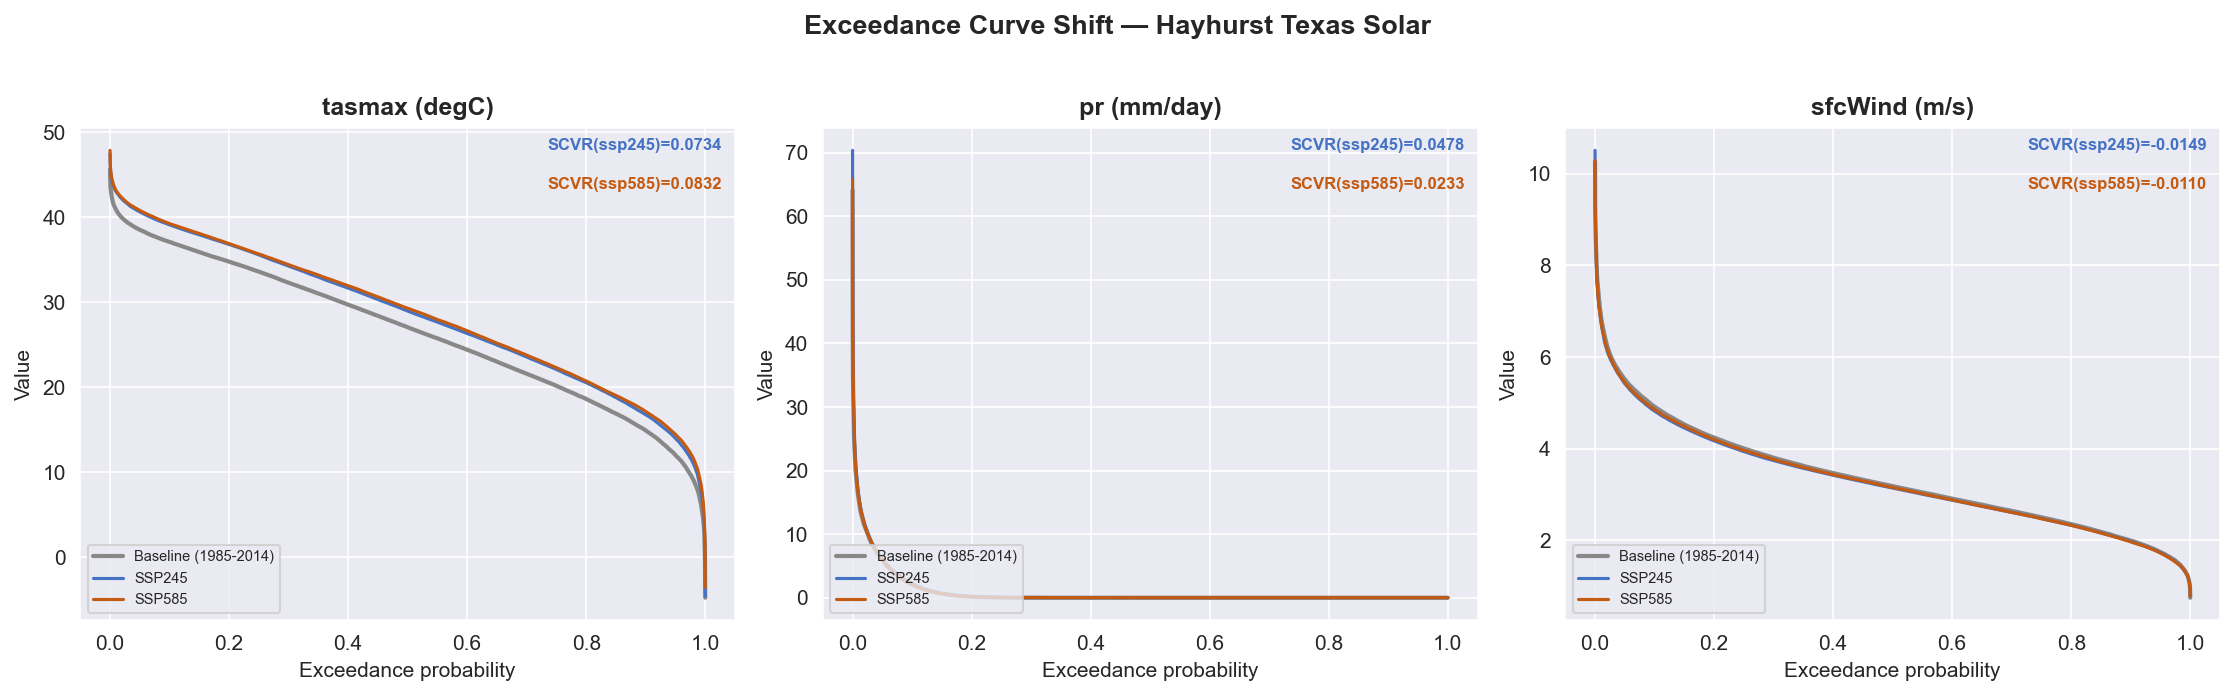

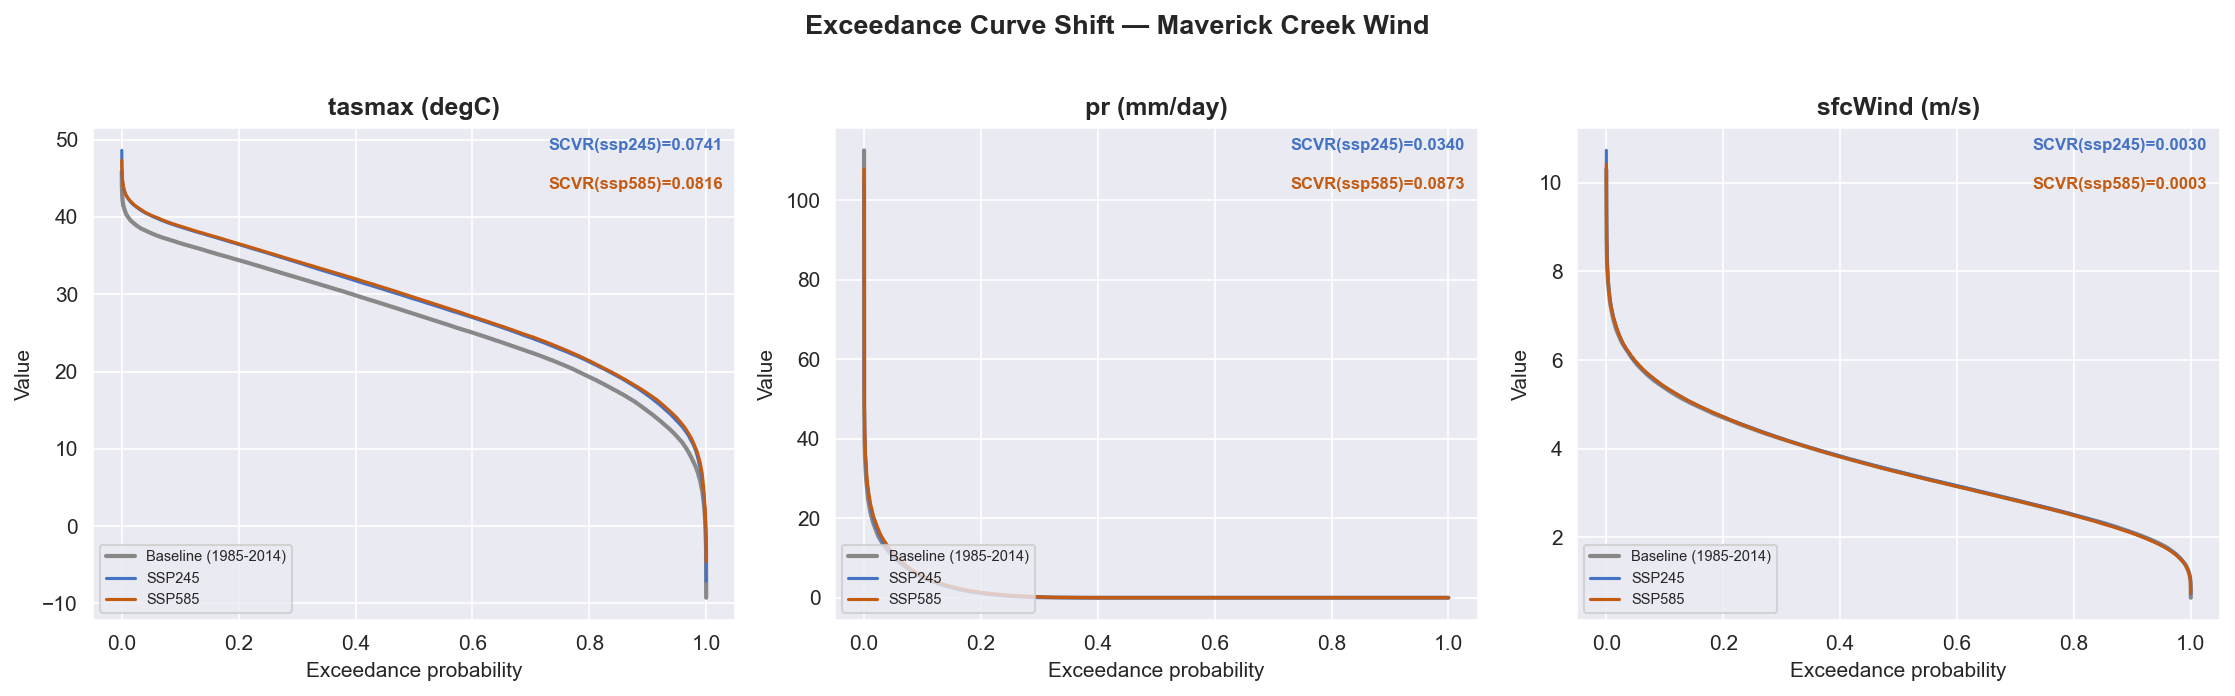

In [11]:
# ── Plot A: Exceedance Curve Shift ────────────────────────────────────────────
# Show baseline vs future exceedance curves for key variables per site

KEY_VARS = ["tasmax", "pr", "sfcWind"]  # subset for readability

for sid in SITE_CONFIGS:
    cfg = SITE_CONFIGS[sid]
    site_vars = [v for v in KEY_VARS if v in SITE_VARIABLES[sid]]
    n_vars = len(site_vars)

    fig, axes = plt.subplots(1, n_vars, figsize=(5 * n_vars, 4.5))
    if n_vars == 1:
        axes = [axes]

    for ax, var in zip(axes, site_vars):
        for scen in SCENARIOS:
            entry = DATA.get((sid, var, scen))
            if entry is None or not entry["models"]:
                continue

            # Pool all models
            base_vals = np.concatenate([s.values for s in entry["baseline_daily"].values()])
            fut_vals  = np.concatenate([s.values for s in entry["future_daily"].values()])

            bv, bp = exceedance_curve(base_vals)
            fv, fp = exceedance_curve(fut_vals)

            # Only plot baseline once (same for both scenarios)
            if scen == SCENARIOS[0]:
                ax.plot(bp, bv, color=BASELINE_COLOR, lw=2, label="Baseline (1985-2014)")

            ax.plot(fp, fv, color=SCENARIO_COLORS[scen], lw=1.5,
                    label=f"{scen.upper()}")

            # Annotate SCVR
            scvr_val = df_ensemble[
                (df_ensemble["site_id"] == sid) &
                (df_ensemble["variable"] == var) &
                (df_ensemble["scenario"] == scen)
            ]["scvr"].values
            if len(scvr_val) > 0:
                ax.text(0.98, 0.98 - (0.08 * SCENARIOS.index(scen)),
                        f"SCVR({scen})={scvr_val[0]:.4f}",
                        transform=ax.transAxes, ha="right", va="top",
                        fontsize=8, color=SCENARIO_COLORS[scen],
                        fontweight="bold")

        var_info = VARS_RAW.get(var, {})
        unit = var_info.get("unit", "")
        ax.set_title(f"{var} ({unit})", fontweight="bold")
        ax.set_xlabel("Exceedance probability")
        ax.set_ylabel("Value")
        ax.legend(fontsize=7, loc="lower left")

    fig.suptitle(f"Exceedance Curve Shift — {cfg['name']}", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

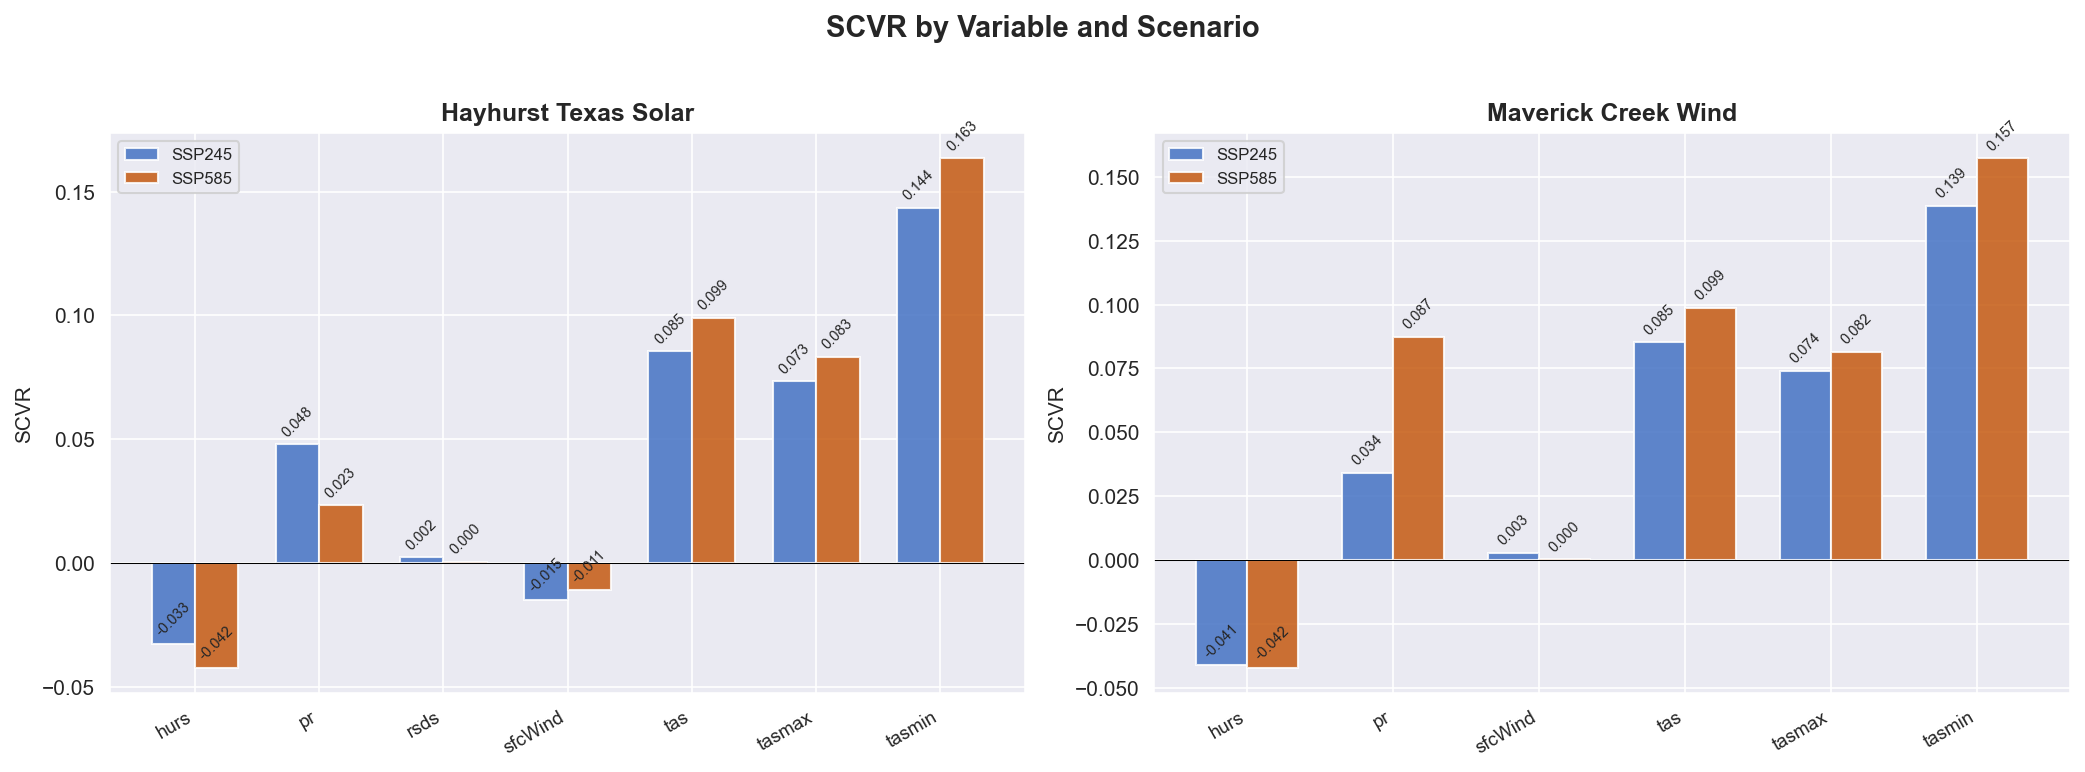

In [12]:
# ── Plot B: SCVR Bar Chart ────────────────────────────────────────────────────
# Grouped bars: SSP245 (blue) vs SSP585 (red), one subplot per site

fig, axes = plt.subplots(1, len(SITE_CONFIGS), figsize=(7 * len(SITE_CONFIGS), 5))
if len(SITE_CONFIGS) == 1:
    axes = [axes]

for ax, (sid, cfg) in zip(axes, SITE_CONFIGS.items()):
    site_df = df_ensemble[df_ensemble["site_id"] == sid]
    if site_df.empty:
        continue

    vars_present = site_df["variable"].unique()
    x = np.arange(len(vars_present))
    width = 0.35

    for i, scen in enumerate(SCENARIOS):
        scen_df = site_df[site_df["scenario"] == scen].set_index("variable")
        vals = [scen_df.loc[v, "scvr"] if v in scen_df.index else 0 for v in vars_present]
        bars = ax.bar(x + i * width, vals, width, label=scen.upper(),
                      color=SCENARIO_COLORS[scen], alpha=0.85, edgecolor="white")
        # Value labels
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=7, rotation=45)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(vars_present, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("SCVR")
    ax.set_title(cfg["name"], fontweight="bold")
    ax.axhline(0, color="black", lw=0.5)
    ax.legend(fontsize=8)

fig.suptitle("SCVR by Variable and Scenario", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# ── Helpers for spaghetti viz (ported from nb02) ─────────────────────────────

def temporal_aggregate(series, agg="annual_mean"):
    """Aggregate a daily pd.Series to annual/monthly/seasonal means."""
    if agg == "annual_mean":
        return series.resample("YE").mean()
    elif agg == "annual_sum":
        return series.resample("YE").sum()
    elif agg == "monthly_mean":
        return series.resample("ME").mean()
    raise ValueError(f"Unknown aggregation: {agg}")

def compute_stats(df):
    """Compute ensemble percentiles and mean across model columns."""
    if df.empty or df.shape[1] == 0:
        return pd.DataFrame()
    return pd.DataFrame({
        "p10":  df.quantile(0.10, axis=1),
        "p25":  df.quantile(0.25, axis=1),
        "p50":  df.quantile(0.50, axis=1),
        "p75":  df.quantile(0.75, axis=1),
        "p90":  df.quantile(0.90, axis=1),
        "mean": df.mean(axis=1),
    })

print("Aggregation helpers defined")

Aggregation helpers defined


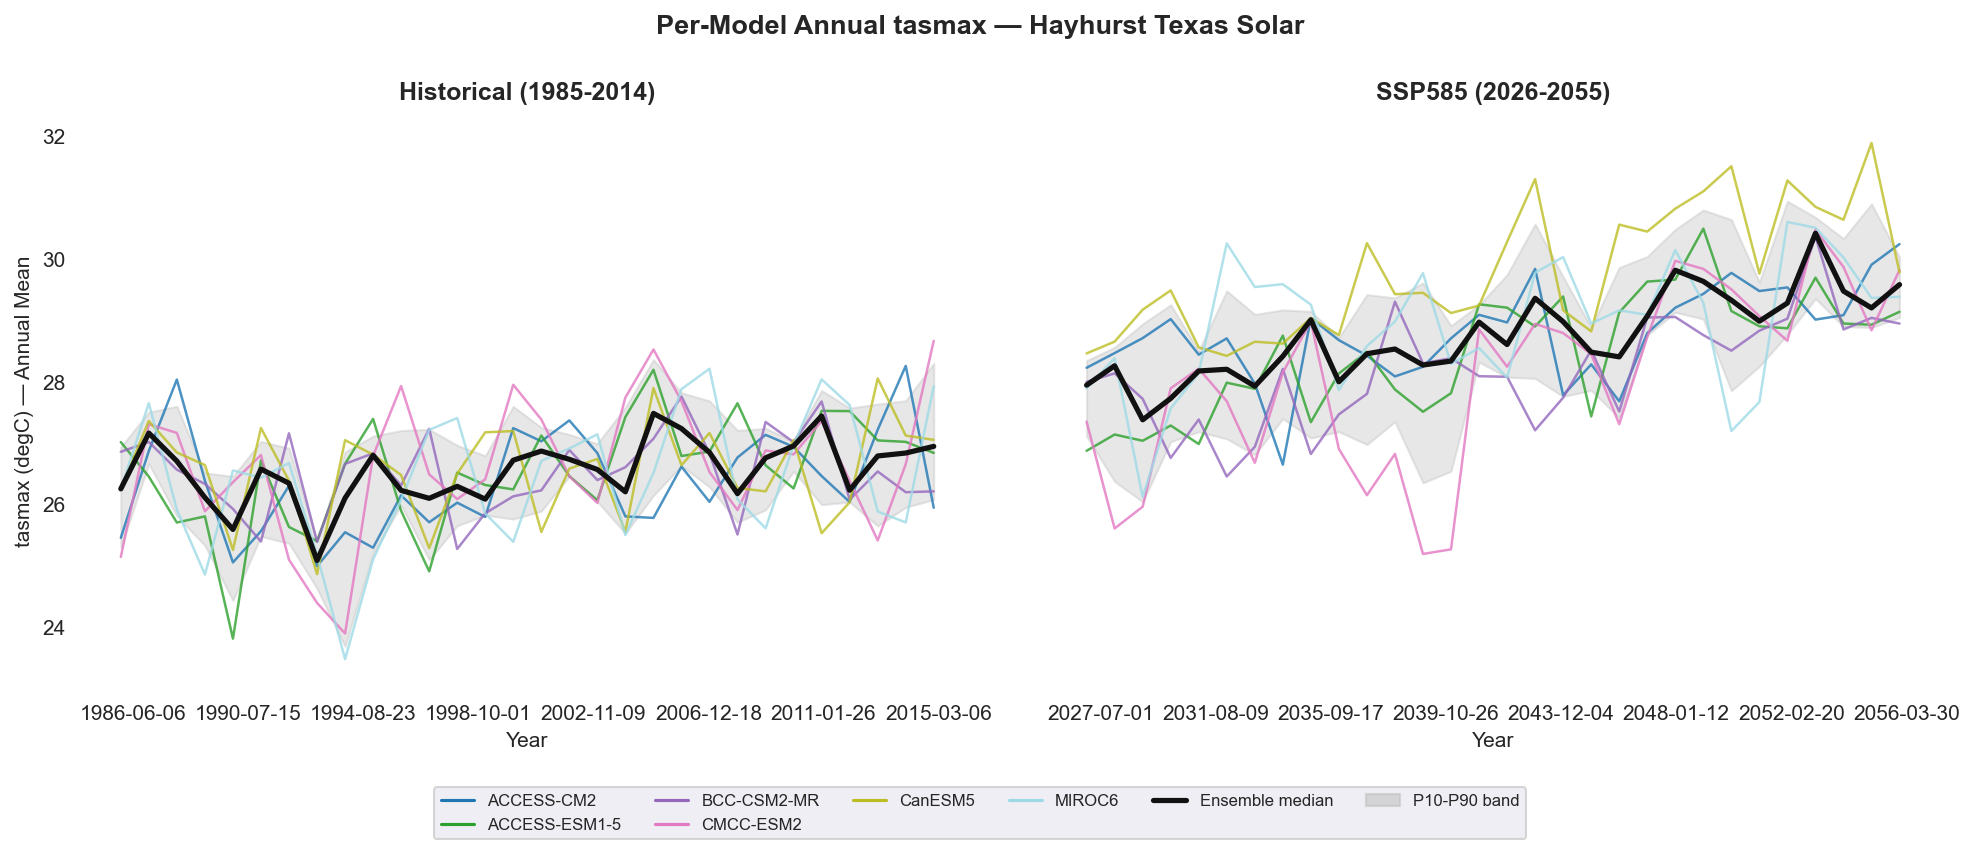

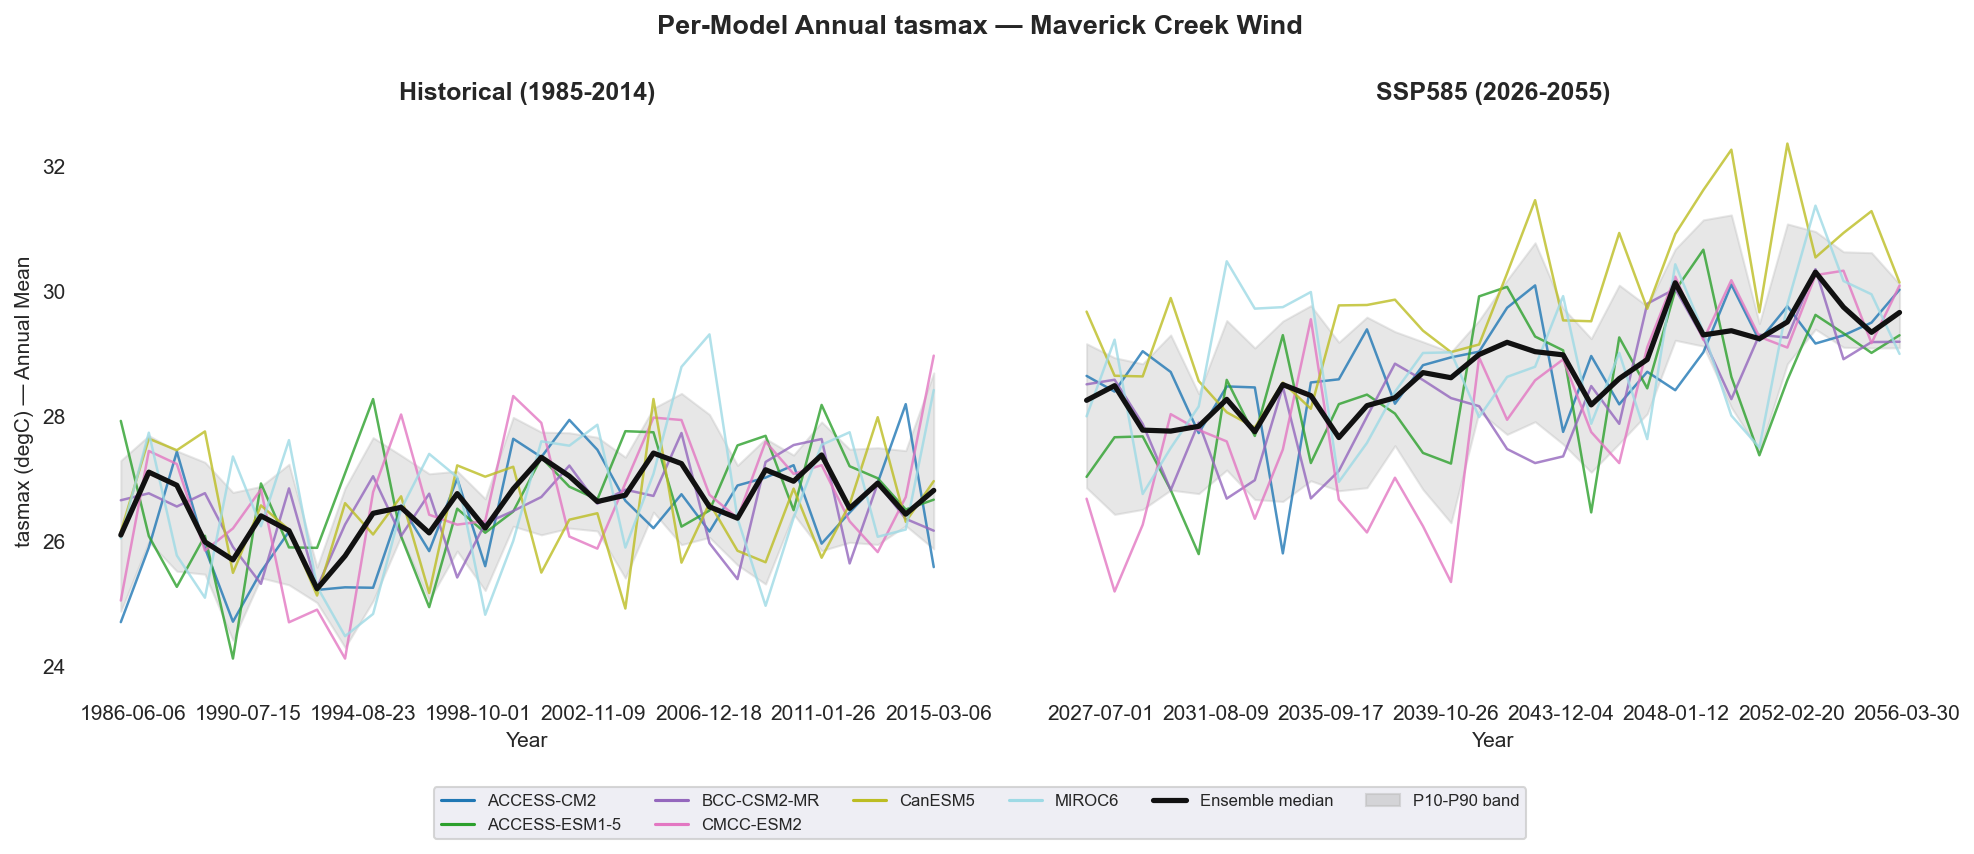

In [14]:
# ── Plot C: Spaghetti Time Series ─────────────────────────────────────────────
# For tasmax per site: baseline (left) vs future (right), each model as thin line

SPAGHETTI_VAR = "tasmax"
AGG = "annual_mean"

for sid in SITE_CONFIGS:
    cfg = SITE_CONFIGS[sid]
    future_start = cfg["construction_start_year"]
    future_end = future_start + cfg["operational_lifespan"] - 1

    # Use ssp585 for the future panel
    scen = "ssp585"
    entry = DATA.get((sid, SPAGHETTI_VAR, scen))
    if entry is None or not entry["models"]:
        print(f"  Skip spaghetti for {sid} — no data")
        continue

    models = entry["models"]

    # Aggregate daily -> annual for each model
    base_annual = pd.DataFrame({
        m: temporal_aggregate(entry["baseline_daily"][m], AGG)
        for m in models
    })
    fut_annual = pd.DataFrame({
        m: temporal_aggregate(entry["future_daily"][m], AGG)
        for m in models
    })

    base_stats = compute_stats(base_annual)
    fut_stats  = compute_stats(fut_annual)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"wspace": 0.08})
    fig.patch.set_facecolor("white")

    panels = [
        (axes[0], base_annual, base_stats, f"Historical ({BASELINE_YEARS[0]}-{BASELINE_YEARS[1]})"),
        (axes[1], fut_annual, fut_stats, f"{scen.upper()} ({future_start}-{future_end})"),
    ]

    # Shared y-limits
    all_vals = pd.concat([base_annual, fut_annual]).values.flatten()
    all_vals = all_vals[~np.isnan(all_vals)]
    y_lo = np.nanmin(all_vals) - 0.5
    y_hi = np.nanmax(all_vals) + 0.5

    for ax, df, stats, title in panels:
        ax.set_facecolor("white")
        # P10-P90 band
        ax.fill_between(stats.index, stats["p10"], stats["p90"],
                        color="#bbbbbb", alpha=0.35, label="P10-P90")
        # Model lines
        for m in models:
            color = get_model_color(m, models)
            ax.plot(df.index, df[m], color=color, lw=1.2, alpha=0.8, label=m)
        # Ensemble median
        ax.plot(stats.index, stats["p50"], color="#111", lw=2.5, label="Median")
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Year")
        ax.set_ylim(y_lo, y_hi)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=8))

    axes[0].set_ylabel(f"{SPAGHETTI_VAR} ({VARS_RAW[SPAGHETTI_VAR]['unit']}) — Annual Mean")
    axes[1].set_yticklabels([])

    # Legend
    model_handles = [mlines.Line2D([], [], color=get_model_color(m, models), lw=1.5, label=m)
                     for m in models]
    ens_handles = [
        mlines.Line2D([], [], color="#111", lw=2.5, label="Ensemble median"),
        mpatches.Patch(color="#bbbbbb", alpha=0.5, label="P10-P90 band"),
    ]
    fig.legend(handles=model_handles + ens_handles, loc="lower center",
               ncol=min(len(models) + 2, 6), fontsize=8, bbox_to_anchor=(0.5, -0.1))

    fig.suptitle(f"Per-Model Annual {SPAGHETTI_VAR} — {cfg['name']}",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

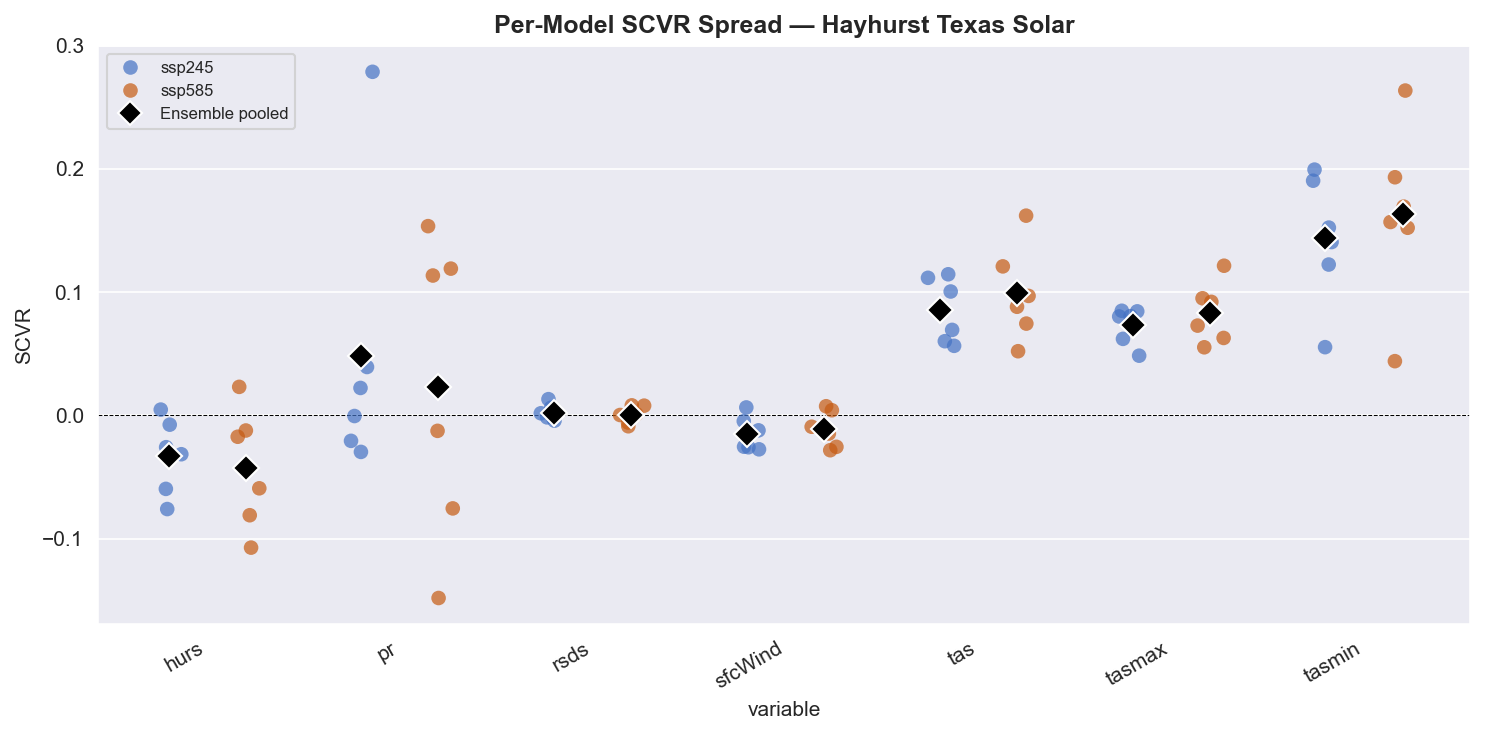

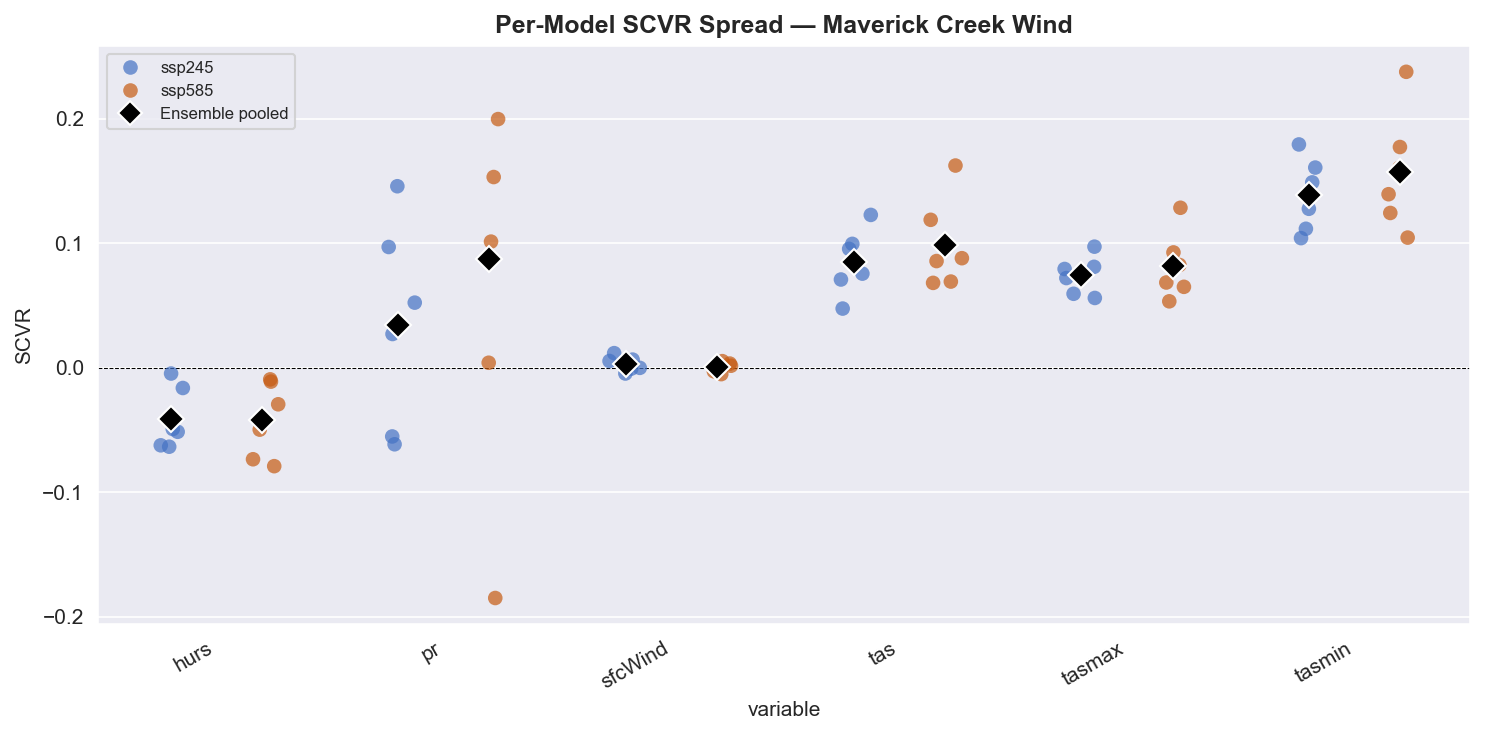

In [15]:
# ── Plot D: Per-Model SCVR Strip Plot ─────────────────────────────────────────
# Shows individual model SCVR as dots — reveals model agreement vs spread

for sid in SITE_CONFIGS:
    cfg = SITE_CONFIGS[sid]
    pm = df_permodel[df_permodel["site_id"] == sid]
    if pm.empty:
        continue

    fig, ax = plt.subplots(figsize=(10, 5))

    sns.stripplot(data=pm, x="variable", y="scvr", hue="scenario",
                  dodge=True, jitter=0.15, size=7, alpha=0.7,
                  palette=SCENARIO_COLORS, ax=ax)

    # Overlay ensemble mean as diamonds
    ens = df_ensemble[df_ensemble["site_id"] == sid]
    for i, var in enumerate(pm["variable"].unique()):
        for j, scen in enumerate(SCENARIOS):
            val = ens[(ens["variable"] == var) & (ens["scenario"] == scen)]["scvr"].values
            if len(val) > 0:
                offset = -0.2 + j * 0.4
                ax.plot(i + offset, val[0], marker="D", color="black",
                        markersize=9, zorder=5, markeredgecolor="white", markeredgewidth=1)

    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_ylabel("SCVR")
    ax.set_title(f"Per-Model SCVR Spread — {cfg['name']}", fontweight="bold")

    # Custom legend
    handles, labels = ax.get_legend_handles_labels()
    handles.append(mlines.Line2D([], [], marker="D", color="black", linestyle="None",
                                  markersize=8, markeredgecolor="white", label="Ensemble pooled"))
    ax.legend(handles=handles, fontsize=8)

    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

In [ ]:
# ── Plot E: Decade-Resolved Exceedance Curves ─────────────────────────────────
# Shows baseline + 3 future decades per scenario — reveals shape changes over time
# (Addresses Prashant's concern: "curves show only shift, not shape/slope change")
#
# Layout: 2×2 for temperature (top=full, bottom=tail zoom with GPD+GEV)
#         1×2 for non-temperature (full only)

DECADE_COLORS = {
    "2026-2035": "#a6cee3",   # light blue → early decade
    "2036-2045": "#1f78b4",   # medium blue → mid decade
    "2046-2055": "#08306b",   # dark blue → late decade
}

PLOT_VARS = ["tasmax", "pr"]  # key variables for exceedance comparison

for sid in SITE_CONFIGS:
    for var in [v for v in SITE_VARIABLES[sid] if v in PLOT_VARS]:
        var_info = VARS_RAW.get(var, {})
        unit = var_info.get("unit", "")
        full_name = var_info.get("full_name", var)
        is_temp = var.startswith("ta")
        nrows = 2 if is_temp else 1

        fig, axes = plt.subplots(nrows, 2, figsize=(16, 6 * nrows), sharey="row",
                                 gridspec_kw={"wspace": 0.05, "hspace": 0.20})
        if nrows == 1:
            axes = axes.reshape(1, -1)

        for col, scen in enumerate(SCENARIOS):
            ax_full = axes[0, col]
            ax_full.set_facecolor("#f9f9f9")
            entry = DATA.get((sid, var, scen))
            if not entry or not entry["models"]:
                ax_full.set_title(f"{scen.upper()} — no data")
                continue

            # Baseline exceedance
            base_vals = np.concatenate([s.values for s in entry["baseline_daily"].values()])
            base_clean = base_vals[~np.isnan(base_vals)]
            bv = np.sort(base_clean)
            bp = 1.0 - np.linspace(0, 1, len(bv))
            ax_full.plot(bv, bp, color="#555555", lw=2.5,
                         label=f"Baseline {BASELINE_YEARS[0]}–{BASELINE_YEARS[1]}", zorder=4)

            base_p90 = float(np.percentile(base_clean, 90))
            base_p95 = float(np.percentile(base_clean, 95))

            # Per-decade exceedance curves
            future_dict = {m: entry["future_daily"][m] for m in entry["models"]}
            dec_data = {}
            for label, start, end in DECADE_WINDOWS:
                dec_pool = pool_window(future_dict, start, end)
                dec_clean = dec_pool[~np.isnan(dec_pool)]
                if len(dec_clean) == 0:
                    continue
                dec_data[label] = dec_clean
                dv = np.sort(dec_clean)
                dp = 1.0 - np.linspace(0, 1, len(dv))
                ax_full.plot(dv, dp, color=DECADE_COLORS[label], lw=2.0,
                             label=label, zorder=3)

            # P90 reference
            ax_full.axhline(0.10, color="black", lw=0.8, ls="--", alpha=0.4)
            ax_full.set_title(f"{scen.upper()}", fontweight="bold")
            ax_full.set_xlabel(f"{full_name} ({unit})")
            ax_full.set_ylim(0, 1)
            ax_full.legend(fontsize=7, loc="upper right")

            # Row 2: Tail zoom with GPD + GEV (temperature only)
            if is_temp:
                ax_tail = axes[1, col]
                ax_tail.set_facecolor("#faf5f0")

                # Re-plot empirical curves zoomed
                ax_tail.plot(bv, bp, color="#555555", lw=2.5, label="Baseline", zorder=4)
                for label in dec_data:
                    dv = np.sort(dec_data[label])
                    dp = 1.0 - np.linspace(0, 1, len(dv))
                    ax_tail.plot(dv, dp, color=DECADE_COLORS[label], lw=2.0,
                                 label=label, zorder=3)

                # Tail x-range for parametric fits
                x_tail = np.linspace(base_p90, base_clean.max() * 1.08, 300)

                # GPD fits (same probability space as empirical daily)
                gpd_base = fit_gpd(entry["baseline_daily"], threshold_quantile=0.95)
                if gpd_base:
                    gx, gp = exceedance_curve_gpd(
                        gpd_base["shape"], gpd_base["scale"],
                        gpd_base["threshold"], gpd_base["exceedance_rate"], x_tail)
                    ax_tail.plot(gx, gp, color="#555555", ls="--", lw=1.8, alpha=0.7,
                                 label="GPD fit (baseline)", zorder=5)

                # Late decade GPD
                late_dict = {}
                for m, s in future_dict.items():
                    mask = (s.index.year >= 2046) & (s.index.year <= 2055)
                    late_dict[m] = s[mask]
                gpd_late = fit_gpd(late_dict, threshold_quantile=0.95)
                if gpd_late:
                    gx, gp = exceedance_curve_gpd(
                        gpd_late["shape"], gpd_late["scale"],
                        gpd_late["threshold"], gpd_late["exceedance_rate"], x_tail)
                    ax_tail.plot(gx, gp, color=DECADE_COLORS["2046-2055"], ls="--", lw=1.8,
                                 alpha=0.7, label="GPD fit (2046-55)", zorder=5)

                # GEV fits (annual max context — different probability space)
                gev_base = gev_results.get((sid, var, scen, "baseline"))
                if gev_base:
                    gx, gp = exceedance_curve_gev(
                        gev_base["shape"], gev_base["loc"], gev_base["scale"], x_tail)
                    ax_tail.plot(gx, gp, color="#555555", ls=":", lw=1.3, alpha=0.5,
                                 label="GEV (ann. max, baseline)", zorder=2)

                gev_late = gev_results.get((sid, var, scen, "2046-2055"))
                if gev_late:
                    gx, gp = exceedance_curve_gev(
                        gev_late["shape"], gev_late["loc"], gev_late["scale"], x_tail)
                    ax_tail.plot(gx, gp, color=DECADE_COLORS["2046-2055"], ls=":", lw=1.3,
                                 alpha=0.5, label="GEV (ann. max, 2046-55)", zorder=2)

                # P95 threshold marker
                ax_tail.axvline(base_p95, color="#999999", ls="-.", lw=0.8, alpha=0.5)
                ax_tail.text(base_p95, 0.14, " P95", fontsize=7, color="#999999")

                ax_tail.set_xlim(base_p90, base_clean.max() * 1.08)
                ax_tail.set_ylim(0, 0.15)
                ax_tail.set_title(f"{scen.upper()} — Tail Zoom (P > 0.90)",
                                  fontweight="bold", fontsize=10)
                ax_tail.set_xlabel(f"{full_name} ({unit})")
                ax_tail.legend(fontsize=6, loc="upper right")

        axes[0, 0].set_ylabel("Exceedance probability  P(X > x)")
        if is_temp:
            axes[1, 0].set_ylabel("Exceedance probability  P(X > x)")

        fig.suptitle(
            f"Decade-Resolved Exceedance — {full_name}  |  {SITE_CONFIGS[sid]['name']}",
            fontsize=13, fontweight="bold", y=1.01
        )
        caption = ("Each curve uses all models pooled within that decade. "
                   "If tails fan out in later decades, the distribution shape is changing.")
        if is_temp:
            caption += ("\n Bottom row: tail zoom. Dashed = GPD (daily threshold exceedance, "
                        "same probability space). Dotted = GEV (annual block maxima).")
        fig.text(0.5, -0.02, caption, ha="center", fontsize=7.5, color="#555555")
        plt.tight_layout()
        plt.show()

In [ ]:
# ── Plot F: SCVR Annual Progression (Anchor Fit) ─────────────────────────────
# Temperature variables: 3-anchor linear fit → annual SCVR(t) trajectory
# Other variables: decade stepping bars

SCENARIO_COLORS = {"ssp245": "#4472C4", "ssp585": "#C55A11"}

for sid in SITE_CONFIGS:
    temp_vars = [v for v in SITE_VARIABLES[sid] if v in ("tasmax", "tasmin", "tas")]
    if not temp_vars:
        continue

    fig, axes = plt.subplots(1, len(temp_vars), figsize=(5.5 * len(temp_vars), 4.5),
                             squeeze=False)
    axes = axes[0]

    for ax, var in zip(axes, temp_vars):
        ax.set_facecolor("#f9f9f9")
        var_info = VARS_RAW.get(var, {})
        full_name = var_info.get("full_name", var)

        for scen in SCENARIOS:
            color = SCENARIO_COLORS[scen]
            key = (sid, var, scen)

            if key in anchor_results:
                res = anchor_results[key]
                # Fitted line
                ax.plot(res["years"], res["annual"], color=color, lw=2,
                        label=f"{scen.upper()} fit (R²={res['r2']:.3f})")
                # Anchor diamonds
                ax.scatter(res["mids"], res["scvrs"], color=color,
                           s=120, marker="D", zorder=5, edgecolors="white", lw=1.5)

            # Full-window reference line
            ens_row = df_ensemble[
                (df_ensemble["site_id"] == sid) &
                (df_ensemble["variable"] == var) &
                (df_ensemble["scenario"] == scen)
            ]
            if not ens_row.empty:
                ax.axhline(ens_row["scvr"].values[0], color=color, ls=":",
                           alpha=0.5, lw=1)

        ax.set_title(var, fontweight="bold")
        ax.set_xlabel("Year")
        ax.set_ylabel("SCVR")
        ax.legend(fontsize=7)

    fig.suptitle(
        f"SCVR Progression — Temperature  |  {SITE_CONFIGS[sid]['name']}",
        fontsize=13, fontweight="bold", y=1.01
    )
    fig.text(0.5, -0.02,
             "Diamonds = 10-year anchor SCVR (independent, non-overlapping). "
             "Solid line = linear fit. Dotted = full 30-year pooled SCVR (current NB03).",
             ha="center", fontsize=7.5, color="#555555")
    plt.tight_layout()
    plt.show()

# ── Decade stepping for non-temperature variables ─────────────────────────────
for sid in SITE_CONFIGS:
    non_temp = [v for v in SITE_VARIABLES[sid] if v not in ("tasmax", "tasmin", "tas")]
    if not non_temp:
        continue

    fig, axes = plt.subplots(1, len(non_temp), figsize=(3.5 * len(non_temp), 4),
                             squeeze=False)
    axes = axes[0]

    for ax, var in zip(axes, non_temp):
        ax.set_facecolor("#f9f9f9")
        site_dec = df_decade[(df_decade["site_id"] == sid) & (df_decade["variable"] == var)]

        x_labels = [d[0] for d in DECADE_WINDOWS]
        x_pos = np.arange(len(x_labels))
        width = 0.35

        for i, scen in enumerate(SCENARIOS):
            color = SCENARIO_COLORS[scen]
            scen_dec = site_dec[site_dec["scenario"] == scen].sort_values("decade")
            if scen_dec.empty:
                continue
            vals = [scen_dec[scen_dec["decade"] == d]["scvr"].values[0]
                    if not scen_dec[scen_dec["decade"] == d].empty else 0
                    for d in x_labels]
            ax.bar(x_pos + i * width - width/2, vals, width, color=color,
                   alpha=0.8, label=scen.upper())
            for j, v in enumerate(vals):
                ax.text(x_pos[j] + i * width - width/2, v, f"{v:+.3f}",
                        ha="center", va="bottom", fontsize=6)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, fontsize=8)
        ax.set_title(var, fontweight="bold")
        ax.set_ylabel("SCVR")
        ax.axhline(0, color="black", lw=0.5, alpha=0.3)
        ax.legend(fontsize=7)

    fig.suptitle(
        f"Decade SCVR — Non-Temperature  |  {SITE_CONFIGS[sid]['name']}",
        fontsize=12, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.show()

In [ ]:
# ── Plot G: Shape Metrics Table ────────────────────────────────────────────────
# Shows variance, skewness, P95, P99 per decade — reveals whether the distribution
# shape is changing (not just shifting)

SHAPE_DISPLAY_COLS = ["period", "mean", "std", "variance", "skewness", "p95", "p99"]

for sid in SITE_CONFIGS:
    print(f"\n{'='*70}")
    print(f"  SHAPE METRICS — {SITE_CONFIGS[sid]['name']}")
    print(f"{'='*70}")

    for var in [v for v in SITE_VARIABLES[sid] if v in ("tasmax", "tasmin", "pr")]:
        var_info = VARS_RAW.get(var, {})
        unit = var_info.get("unit", "")
        print(f"\n  {var} ({unit})  —  SSP5-8.5:")

        mask = ((df_shape["site_id"] == sid) &
                (df_shape["variable"] == var) &
                (df_shape["scenario"] == "ssp585"))
        sub = df_shape[mask].copy()
        if sub.empty:
            print("    (no data)")
            continue

        # Order: baseline, 2026-2035, 2036-2045, 2046-2055
        period_order = ["baseline"] + [d[0] for d in DECADE_WINDOWS]
        sub["_order"] = sub["period"].map({p: i for i, p in enumerate(period_order)})
        sub = sub.sort_values("_order")

        display_cols = [c for c in SHAPE_DISPLAY_COLS if c in sub.columns]
        fmt = sub[display_cols].copy()
        for c in ["mean", "std", "p95", "p99"]:
            if c in fmt.columns:
                fmt[c] = fmt[c].map(lambda x: f"{x:.2f}")
        for c in ["variance"]:
            if c in fmt.columns:
                fmt[c] = fmt[c].map(lambda x: f"{x:.3f}")
        for c in ["skewness"]:
            if c in fmt.columns:
                fmt[c] = fmt[c].map(lambda x: f"{x:+.3f}" if pd.notna(x) else "N/A")

        print(fmt.to_string(index=False))

        # Highlight changes
        baseline_row = sub[sub["period"] == "baseline"]
        late_row = sub[sub["period"] == "2046-2055"]
        if not baseline_row.empty and not late_row.empty:
            b_p99 = baseline_row["p99"].values[0]
            l_p99 = late_row["p99"].values[0]
            b_var = baseline_row["variance"].values[0]
            l_var = late_row["variance"].values[0]
            p99_change = (l_p99 - b_p99) / abs(b_p99) * 100 if b_p99 != 0 else 0
            var_change = (l_var - b_var) / abs(b_var) * 100 if b_var != 0 else 0
            print(f"    → P99 change (baseline→2046-55): {p99_change:+.1f}%")
            print(f"    → Variance change: {var_change:+.1f}%")

# ── GEV shape evolution summary ───────────────────────────────────────────────
if gev_results:
    print(f"\n{'='*70}")
    print("  GEV SHAPE PARAMETER (ξ) EVOLUTION")
    print(f"{'='*70}")
    print("  ξ < 0: light tail  |  ξ ≈ 0: Gumbel (exponential tail)  |  ξ > 0: heavy tail")
    print()

    for sid in SITE_CONFIGS:
        for var in [v for v in SITE_VARIABLES[sid] if v.startswith("ta")]:
            for scen in SCENARIOS:
                vals = []
                for period in ["baseline"] + [d[0] for d in DECADE_WINDOWS]:
                    key = (sid, var, scen, period)
                    if key in gev_results:
                        g = gev_results[key]
                        vals.append(f"{period}: ξ={g['shape']:+.3f} μ={g['loc']:.1f} σ={g['scale']:.2f}")
                if vals:
                    print(f"  {sid:20s}  {var:8s}  {scen:6s}")
                    for v in vals:
                        print(f"    {v}")

In [ ]:
# ── Save Decade SCVR + Shape Metrics Parquet ──────────────────────────────────
# New files alongside existing cmip6_ensemble_scvr.parquet (backward compatible)

for sid in SITE_CONFIGS:
    out_dir = Path(f"../data/processed/scvr/{sid}")
    out_dir.mkdir(parents=True, exist_ok=True)

    # Decade SCVR
    site_dec = df_decade[df_decade["site_id"] == sid]
    if not site_dec.empty:
        dec_path = out_dir / "cmip6_scvr_decade.parquet"
        site_dec.to_parquet(dec_path, index=False)
        print(f"Saved {dec_path}  ({len(site_dec)} rows)")

    # Shape metrics
    site_shape = df_shape[df_shape["site_id"] == sid]
    if not site_shape.empty:
        shape_path = out_dir / "cmip6_shape_metrics.parquet"
        site_shape.to_parquet(shape_path, index=False)
        print(f"Saved {shape_path}  ({len(site_shape)} rows)")

print("\nNew outputs saved alongside existing cmip6_ensemble_scvr.parquet")

## Section 5 — Summary & Interpretation

### What the SCVR numbers mean

| SCVR Range | Magnitude | Physical Meaning |
|:---:|:---:|:---|
| 0.00 – 0.10 | Low | <10% increase in exceedance area — within natural variability |
| 0.10 – 0.30 | Moderate | 10–30% shift — detectable climate trend, warrants monitoring |
| 0.30 – 0.60 | High | 30–60% shift — significant climate impact on asset operations |
| > 0.60 | Very High | >60% shift — review carefully, may indicate tail sensitivity |

**Positive SCVR** = future distribution shifted toward more extreme values (e.g., hotter, wetter).
**Negative SCVR** = future has *fewer* extreme values (e.g., fewer freeze days under warming).

### Financial link
SCVR feeds into:
- **HCR** (Hazard Change Ratio): hazard-specific scaling via published damage functions
- **EFR** (Equipment Failure Ratio): engineering models (Peck's, Coffin-Manson, Palmgren-Miner)
- Both ultimately drive **NAV impairment** estimates (BI losses + IUL shortening)

In [16]:
# ── Final Summary Table ───────────────────────────────────────────────────────

def magnitude_label(scvr):
    abs_s = abs(scvr)
    if abs_s < 0.10:
        return "Low"
    elif abs_s < 0.30:
        return "Moderate"
    elif abs_s < 0.60:
        return "High"
    else:
        return "Very High"

summary_rows = []
for _, row in df_ensemble.iterrows():
    var_info = VARS_RAW.get(row["variable"], {})
    n_models = len(DATA.get((row["site_id"], row["variable"], row["scenario"]), {}).get("models", []))
    summary_rows.append({
        "Site": SITE_CONFIGS[row["site_id"]]["name"],
        "Variable": row["variable"],
        "Scenario": row["scenario"].upper(),
        "SCVR": round(row["scvr"], 4),
        "Magnitude": magnitude_label(row["scvr"]),
        "Direction": var_info.get("scvr_direction", ""),
        "N Models": n_models,
    })

df_summary = pd.DataFrame(summary_rows)

styled_summary = (df_summary.style
    .background_gradient(cmap="RdYlGn_r", subset=["SCVR"], vmin=-0.1, vmax=0.3)
    .set_caption("Final SCVR Summary — All Sites, Variables, Scenarios"))
display(styled_summary)

,Site,Variable,Scenario,SCVR,Magnitude,Direction,N Models
0,Hayhurst Texas Solar,hurs,SSP245,-0.032700,Low,context_dependent,6
1,Hayhurst Texas Solar,hurs,SSP585,-0.042400,Low,context_dependent,6
2,Hayhurst Texas Solar,pr,SSP245,0.047800,Low,extremes_both_directions,6
3,Hayhurst Texas Solar,pr,SSP585,0.023300,Low,extremes_both_directions,6
4,Hayhurst Texas Solar,rsds,SSP245,0.002200,Low,not_primary_scvr_variable,6
5,Hayhurst Texas Solar,rsds,SSP585,0.000500,Low,not_primary_scvr_variable,6
6,Hayhurst Texas Solar,sfcWind,SSP245,-0.014900,Low,higher_extremes_are_worse,6
7,Hayhurst Texas Solar,sfcWind,SSP585,-0.011000,Low,higher_extremes_are_worse,6
8,Hayhurst Texas Solar,tas,SSP245,0.085400,Low,higher_is_worse,6
9,Hayhurst Texas Solar,tas,SSP585,0.099100,Low,higher_is_worse,6


In [17]:
# ── Output Manifest ───────────────────────────────────────────────────────────
from pathlib import Path

print("OUTPUT FILES")
print("=" * 60)
for sid in SITE_CONFIGS:
    parquet_path = Path(f"../data/processed/scvr/{sid}/cmip6_ensemble_scvr.parquet")
    if parquet_path.exists():
        df_check = pd.read_parquet(parquet_path)
        print(f"\n  {parquet_path}")
        print(f"    Rows: {len(df_check)}")
        print(f"    Columns: {list(df_check.columns)}")
        # Verify against schema
        schema_cols = set(SCVR_SCHEMA["columns"].keys())
        actual_cols = set(df_check.columns)
        missing = schema_cols - actual_cols
        if missing:
            print(f"    WARNING: Missing schema columns: {missing}")
        else:
            print(f"    Schema compliance: OK")

print("\n" + "=" * 60)
print("NEXT STEPS")
print("=" * 60)
print("  -> Notebook 04: HCR (Hazard Change Ratio) computation")
print("     Uses SCVR outputs + published damage functions to compute")
print("     hazard-specific impact ratios for each asset.")
print("  -> Notebook 05: EFR (Equipment Failure Ratio)")
print("     Engineering degradation models (Peck's, Coffin-Manson, Palmgren-Miner)")
print("=" * 60)

OUTPUT FILES

  ../data/processed/scvr/hayhurst_solar/cmip6_ensemble_scvr.parquet
    Rows: 14
    Columns: ['site_id', 'scenario', 'model', 'center_year', 'variable', 'scvr', 'area_baseline', 'area_future', 'window_start_year', 'window_end_year', 'n_baseline_days', 'n_future_days']
    Schema compliance: OK

  ../data/processed/scvr/maverick_wind/cmip6_ensemble_scvr.parquet
    Rows: 12
    Columns: ['site_id', 'scenario', 'model', 'center_year', 'variable', 'scvr', 'area_baseline', 'area_future', 'window_start_year', 'window_end_year', 'n_baseline_days', 'n_future_days']
    Schema compliance: OK

NEXT STEPS
  -> Notebook 04: HCR (Hazard Change Ratio) computation
     Uses SCVR outputs + published damage functions to compute
     hazard-specific impact ratios for each asset.
  -> Notebook 05: EFR (Equipment Failure Ratio)
     Engineering degradation models (Peck's, Coffin-Manson, Palmgren-Miner)
